In [1]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Read harmonized data
HARMONIZED_DATA_PATH = Path('../artifacts/asic_harmonized/')
final_static = pd.read_csv(HARMONIZED_DATA_PATH / 'static/harmonized.csv')
final_dynamic = pd.read_csv(HARMONIZED_DATA_PATH / 'dynamic/harmonized.csv')



In [6]:
final_static.columns

Index(['hospital_id', 'stay_id_global', 'stay_id_local', 'age_group', 'sex',
       'height_group', 'weight_group', 'bmi_group', 'hosp_mortality',
       'icu_mortality', 'hosp_los', 'icu_los', 'icu_readmit',
       'dialysis_free_days', 'vent_free_days', 'icd10_codes'],
      dtype='object')

## Missingness Analysis

### ICU vs. Hospital Mortality
Below we see whether a hospital provided the information of whether the patient died in the ICU, or whether we simply have the in-hospital mortality flag.

In [10]:
# Check if icu_mortality is missing for hospital_id
final_static.groupby("hospital_id")["icu_mortality"].apply(lambda x: ~x.isnull().all())

hospital_id
asic_UK00    False
asic_UK01    False
asic_UK02     True
asic_UK03    False
asic_UK04     True
asic_UK06     True
asic_UK07     True
asic_UK08     True
Name: icu_mortality, dtype: bool

### Patient Missingness Patterns
**Findings:**
- `spont_resp_rate` is part of the ventilation family: it is always provided when ventilation parameters are given. It can be imputet with the `resp_rate` at time points where it is missing and the patient is **not** ventilated. 

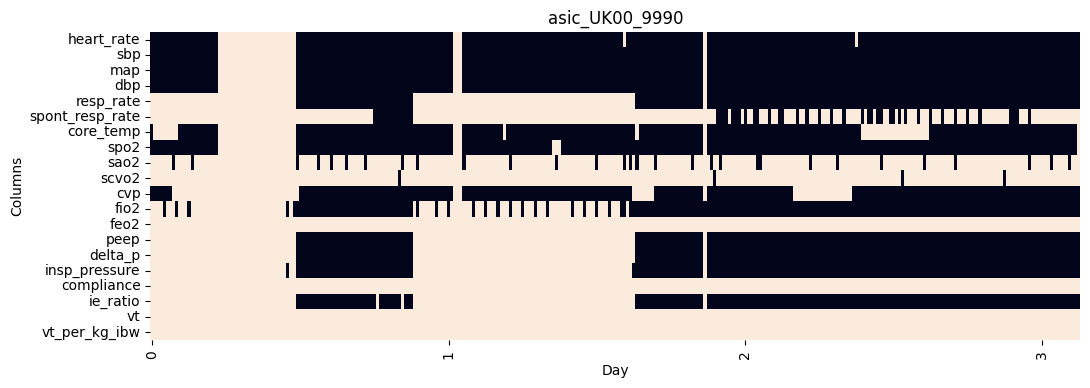

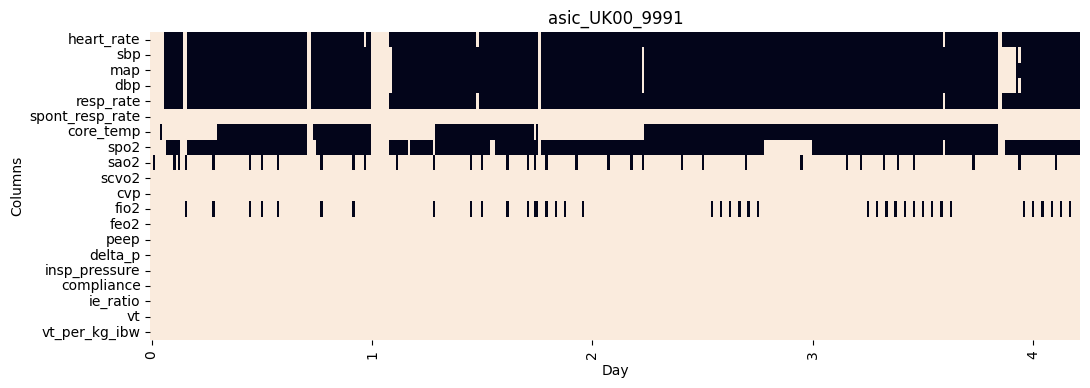

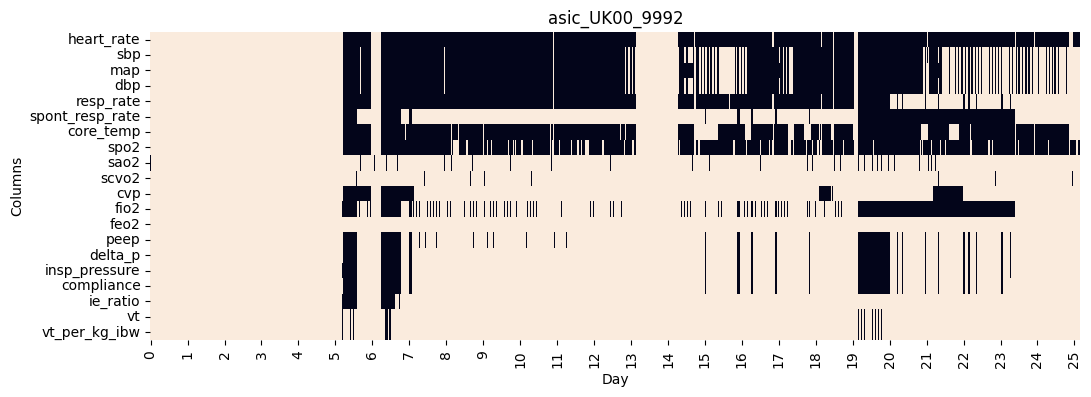

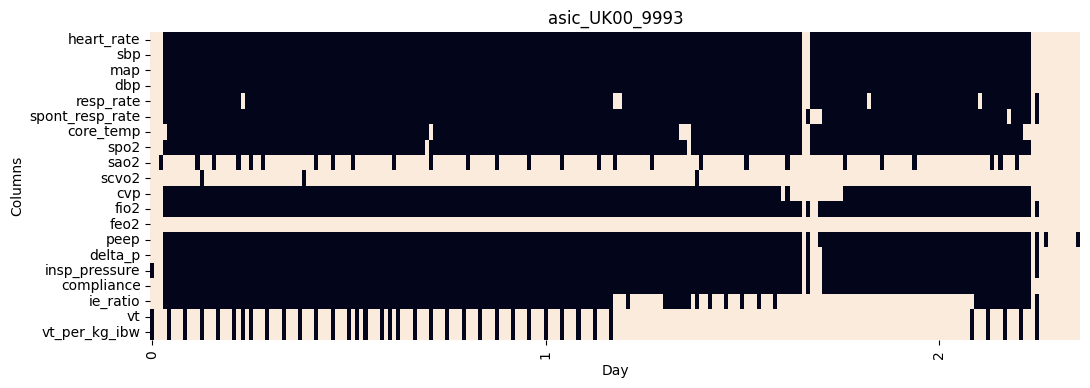

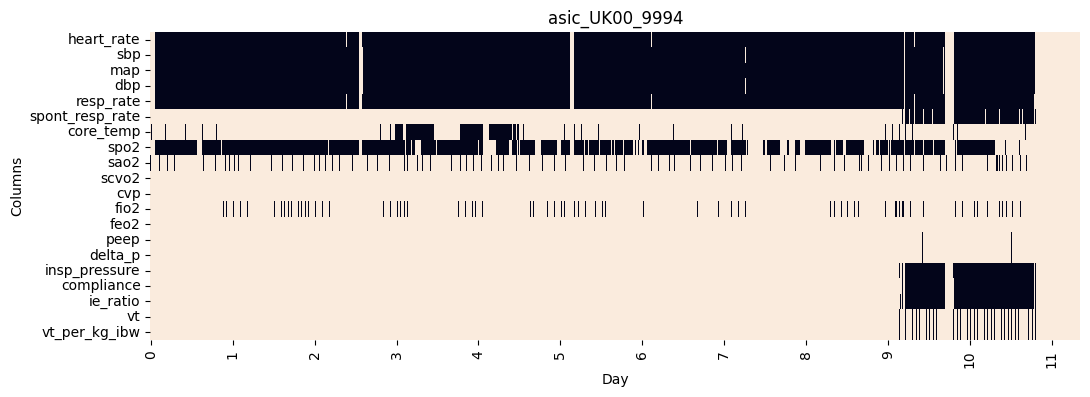

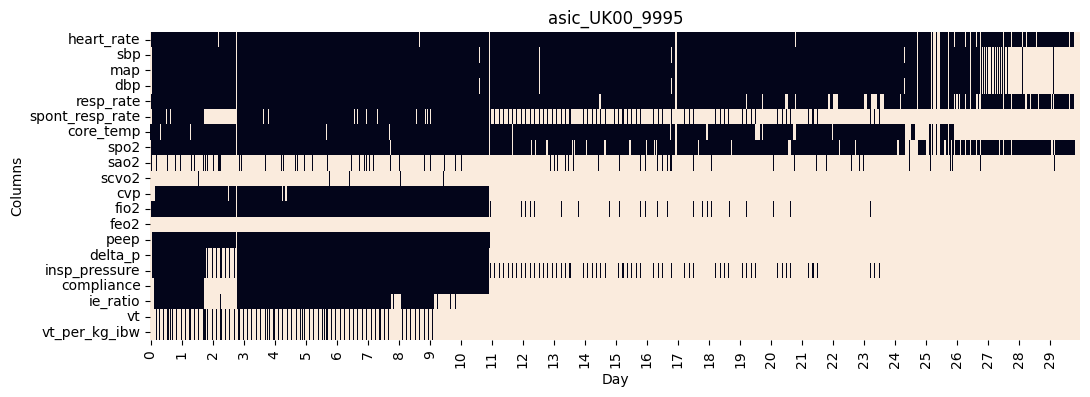

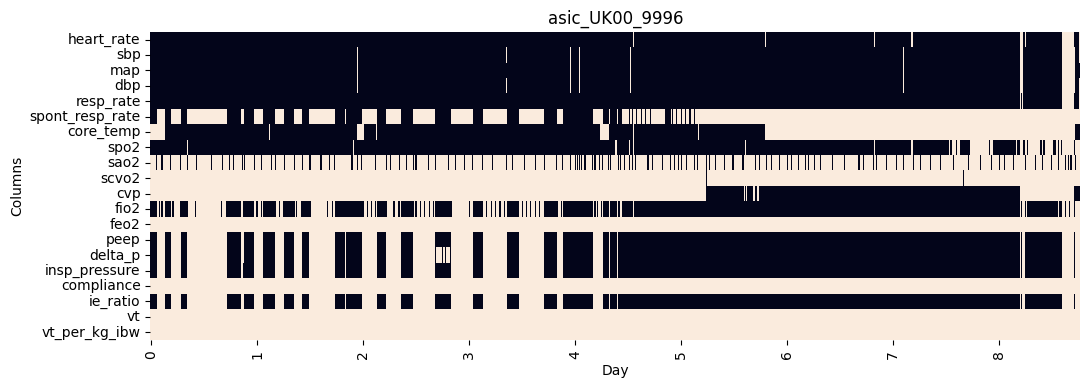

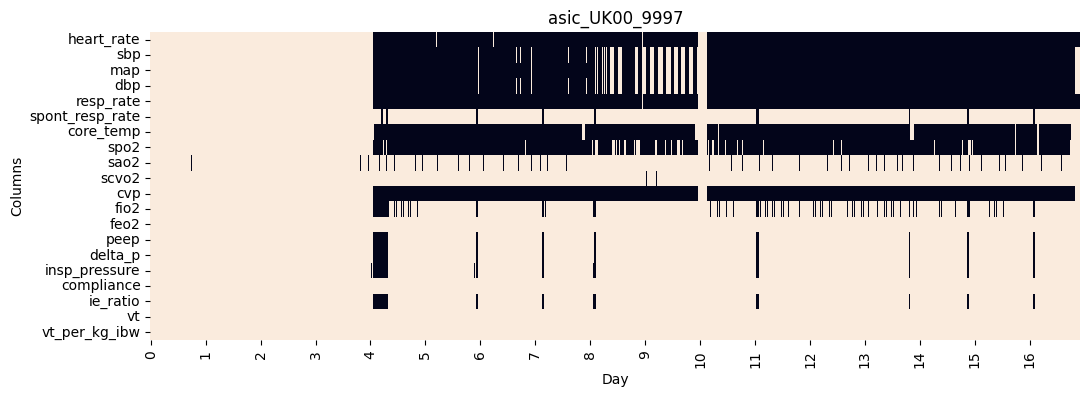

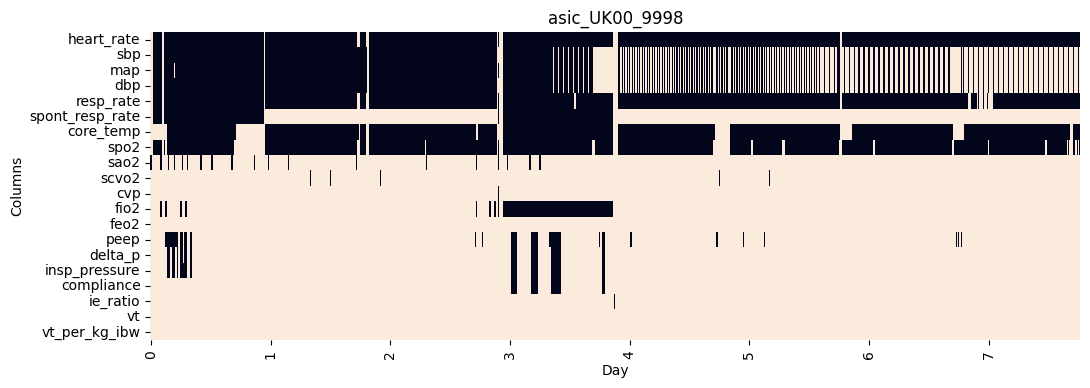

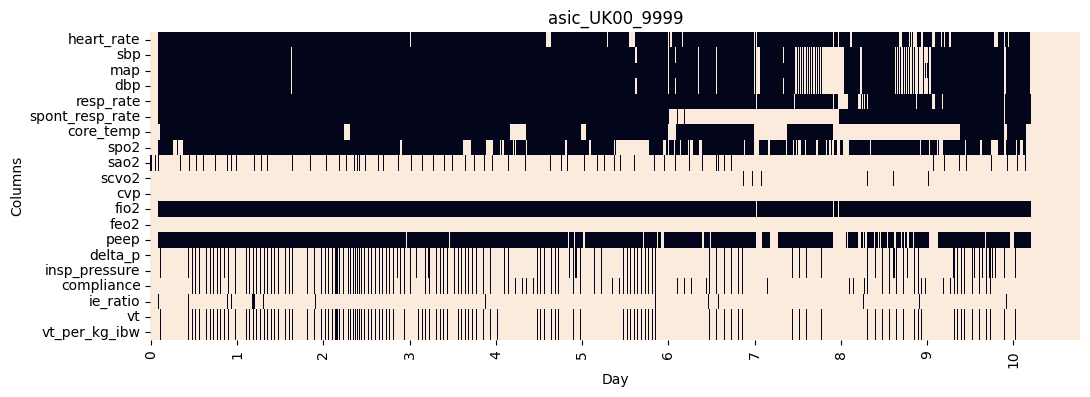

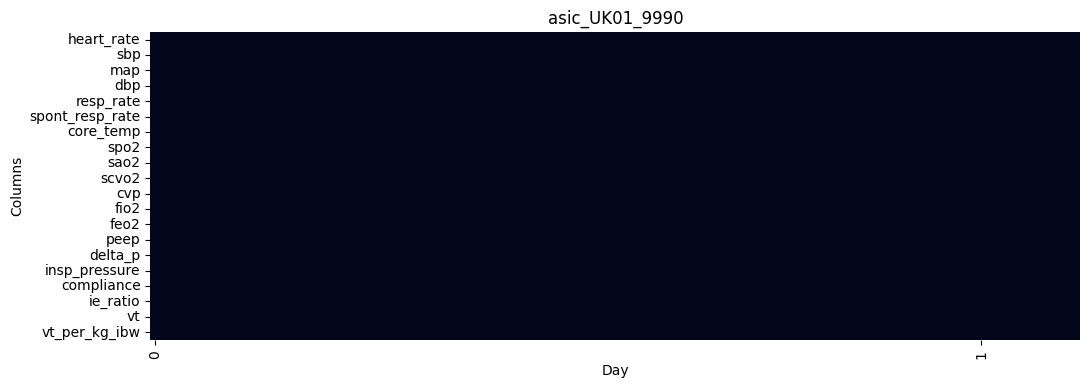

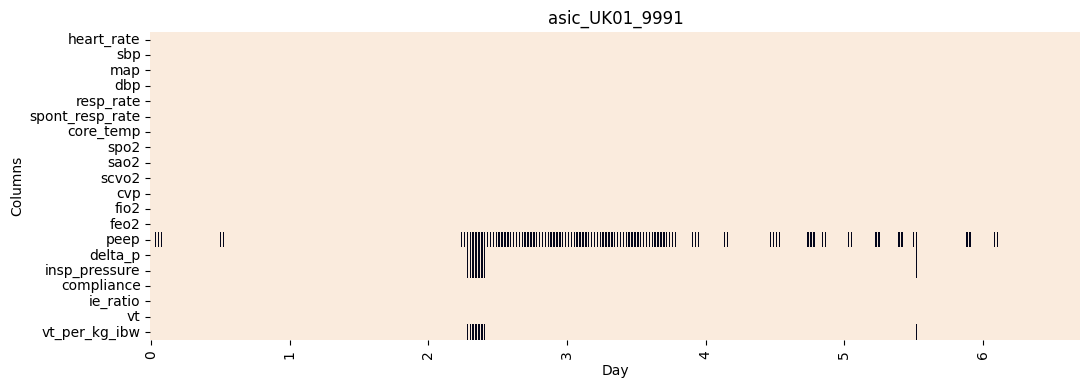

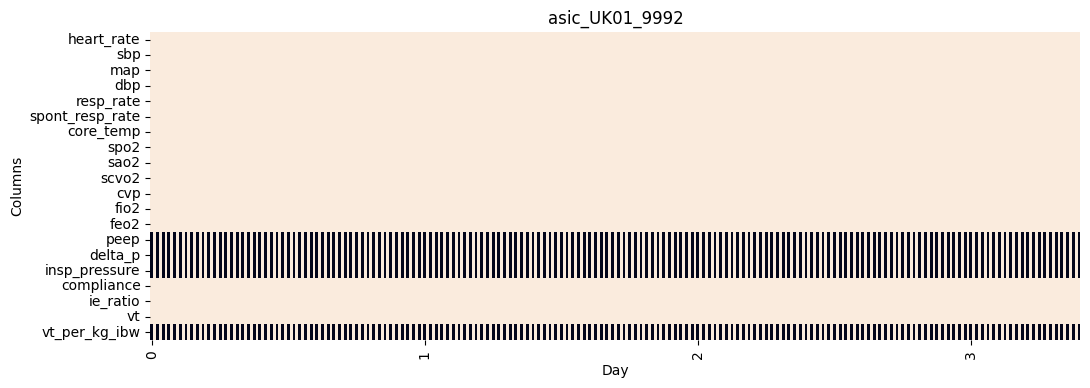

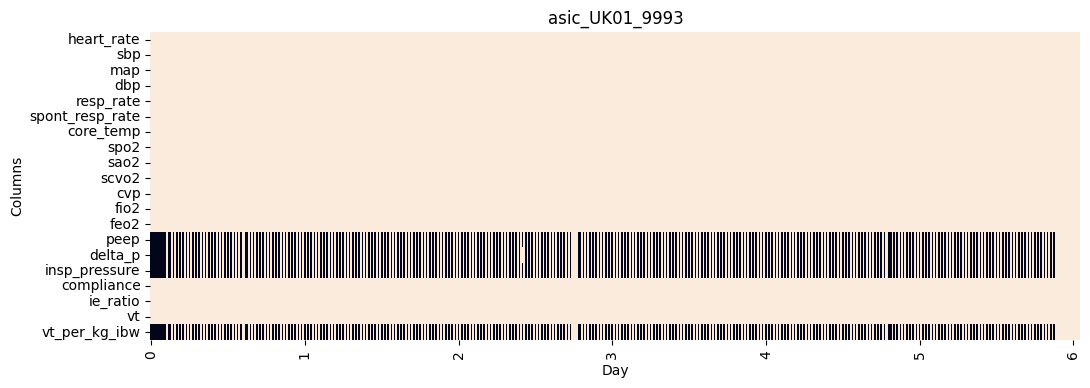

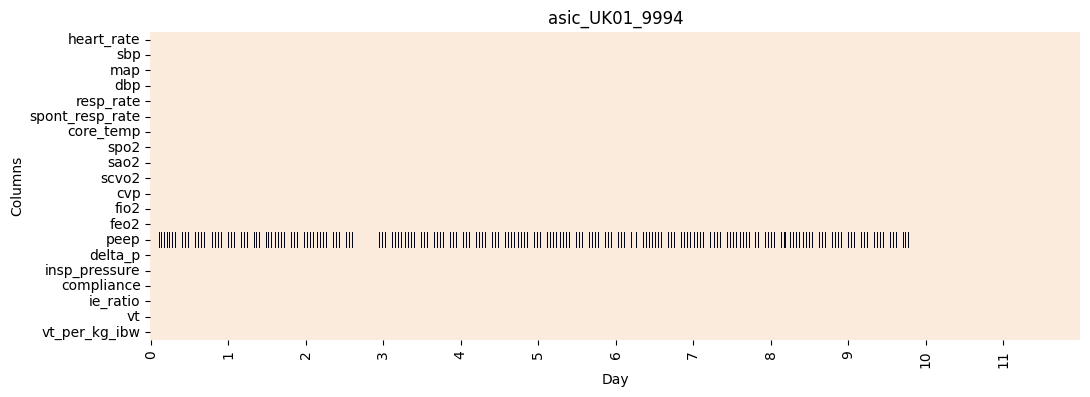

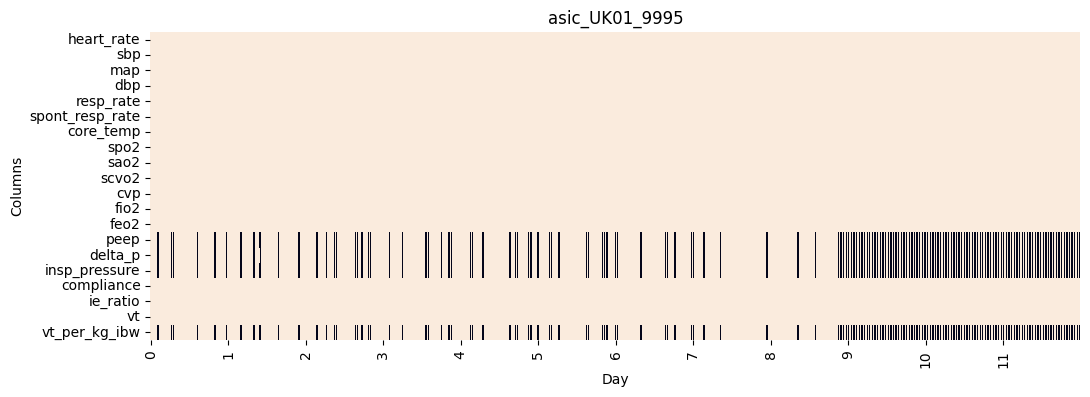

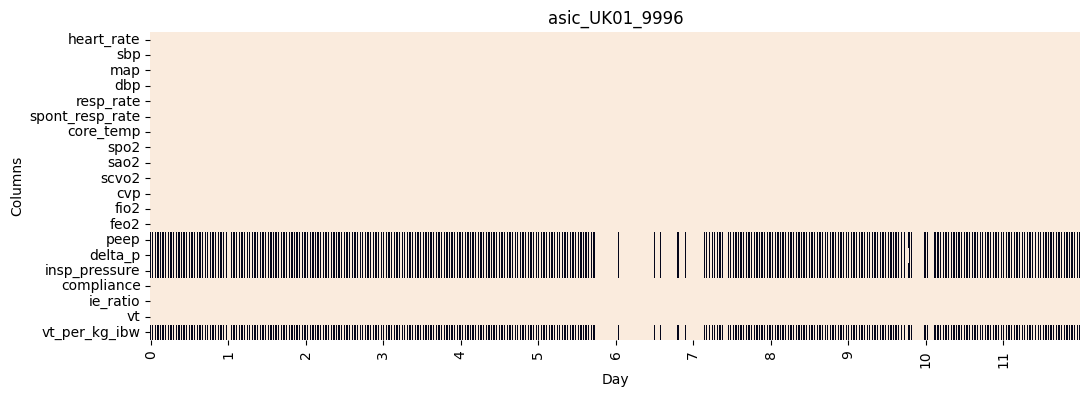

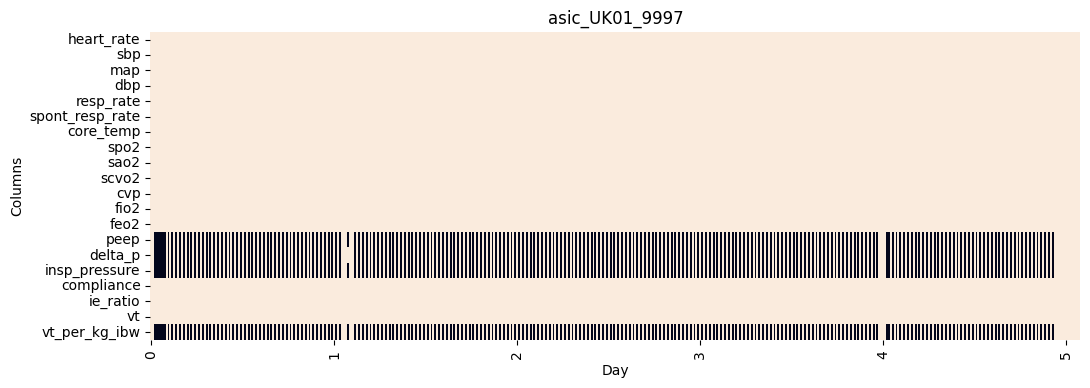

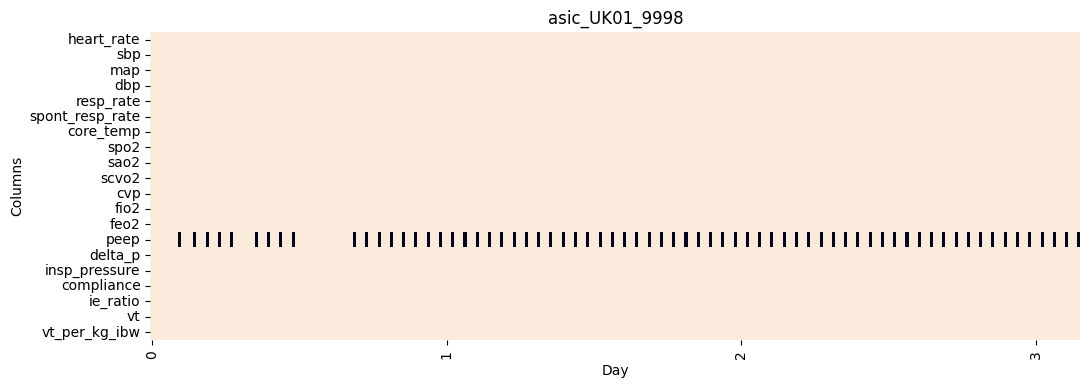

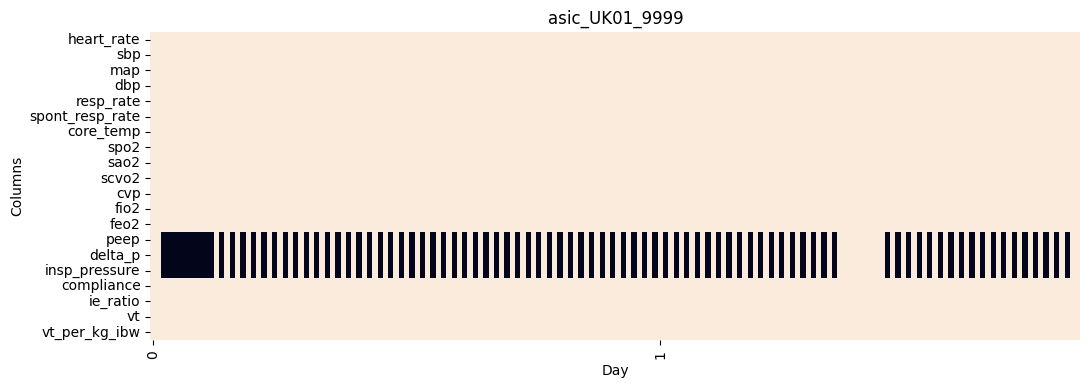

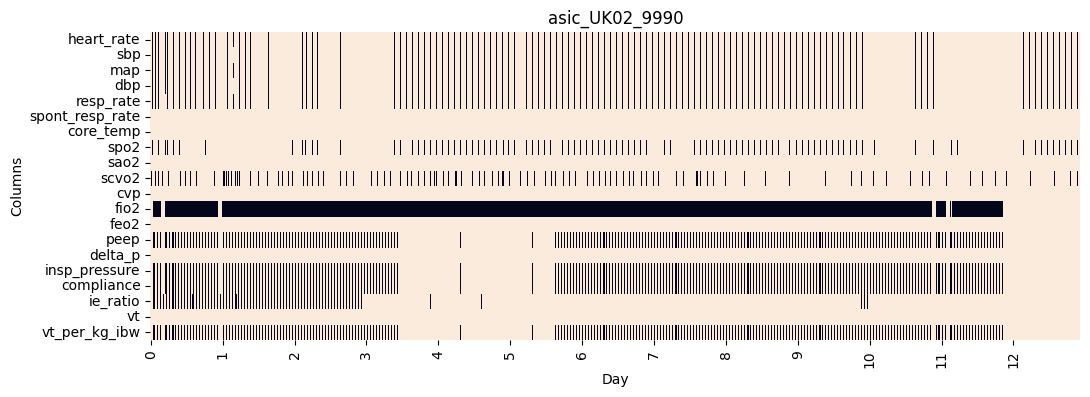

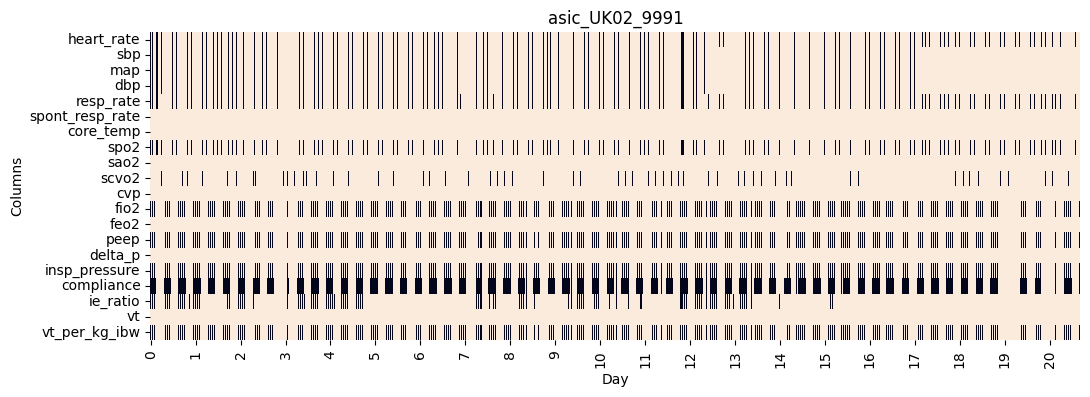

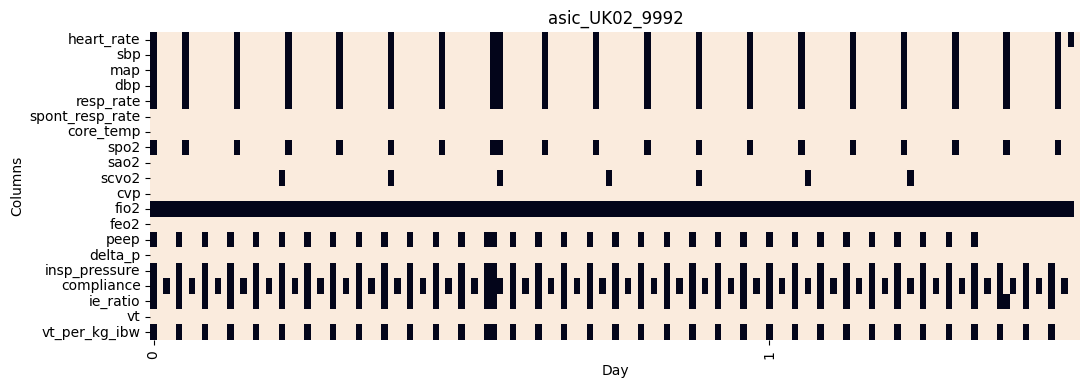

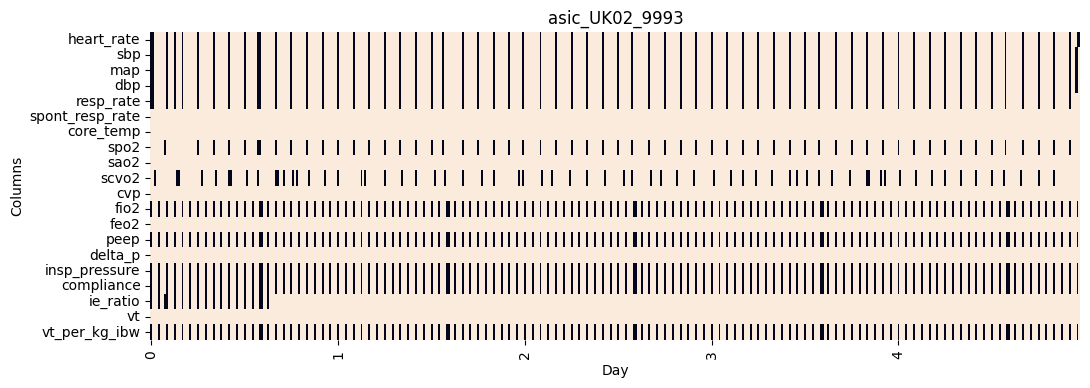

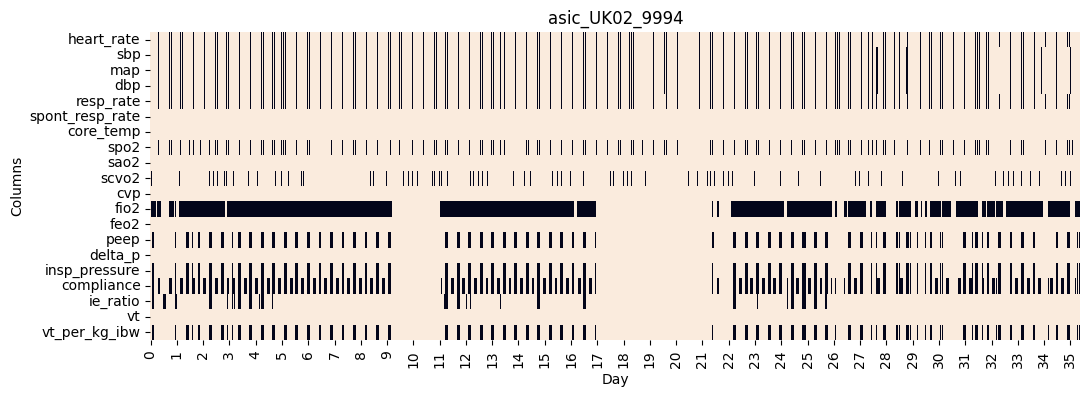

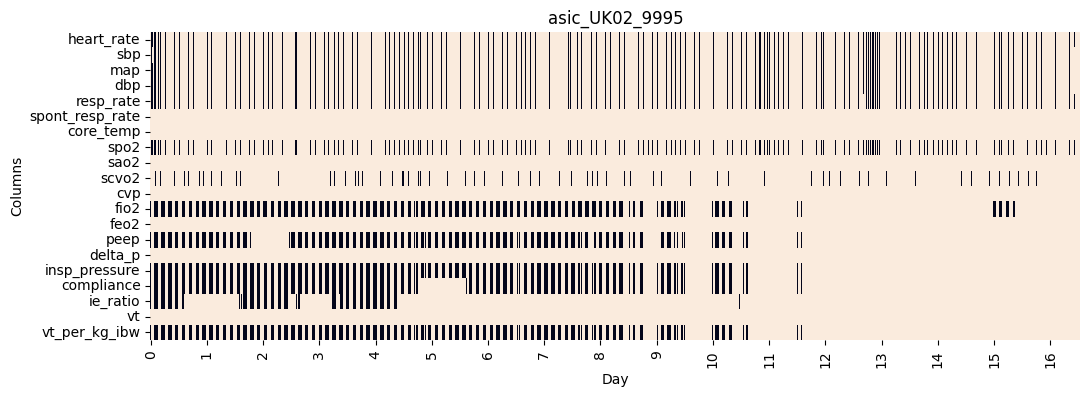

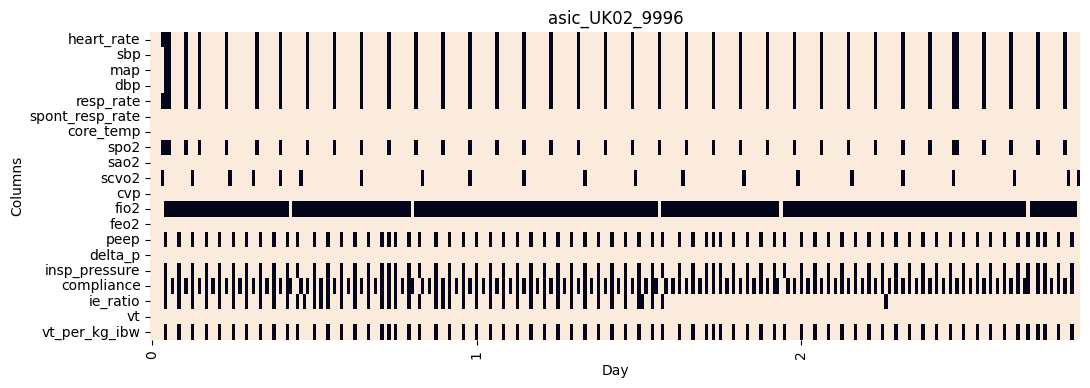

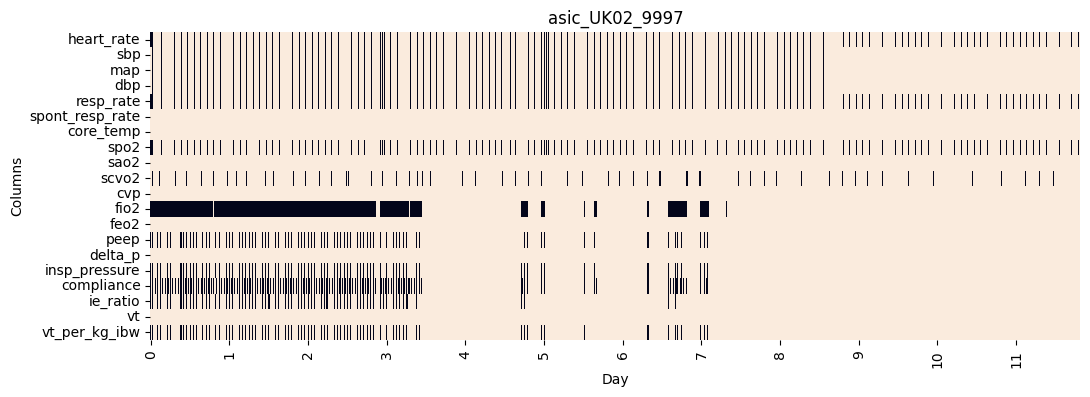

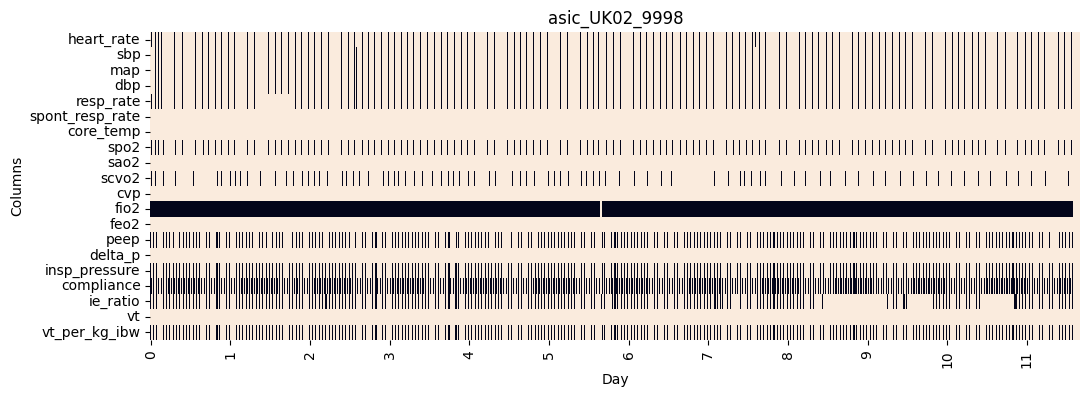

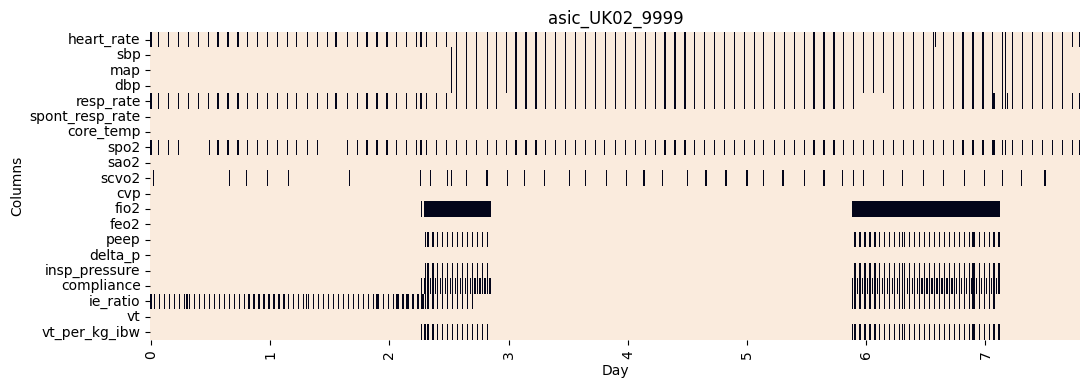

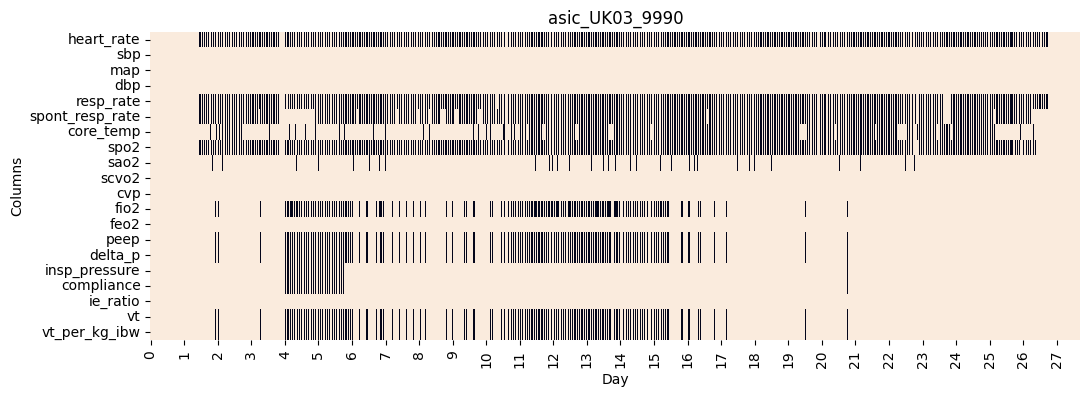

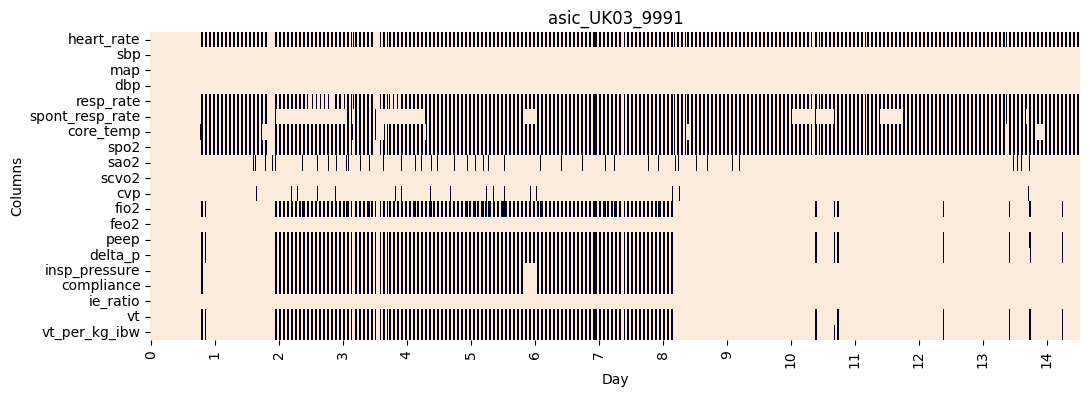

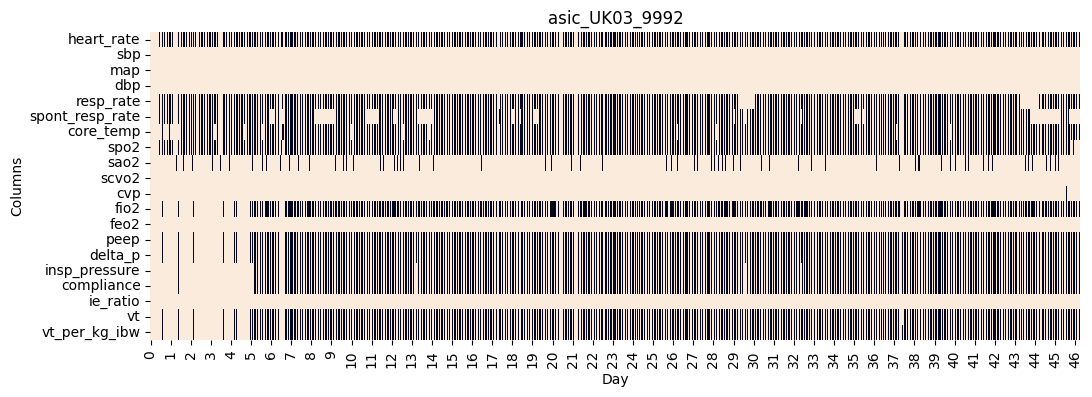

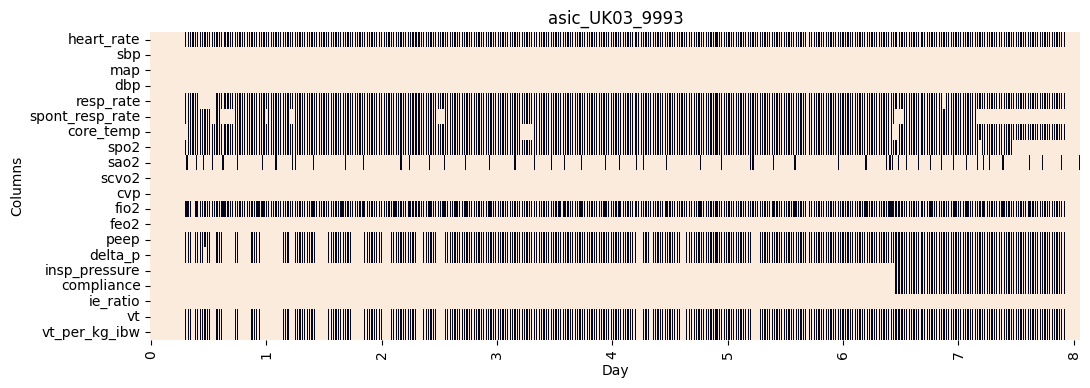

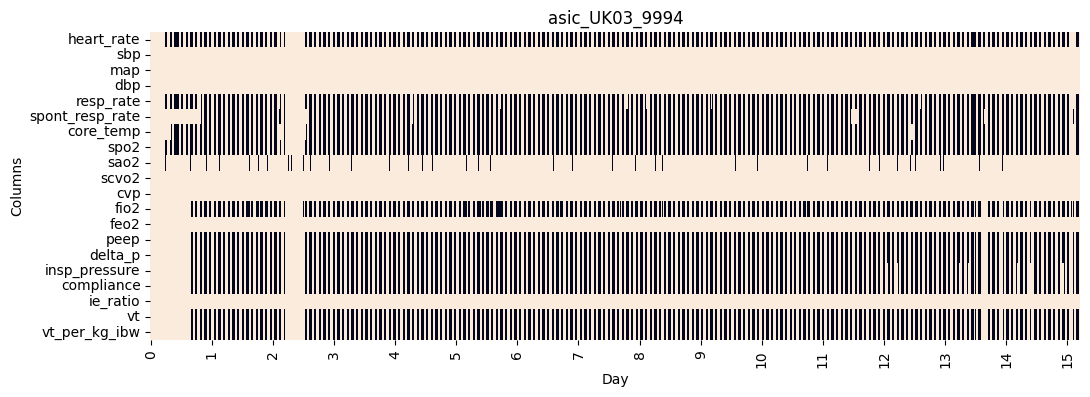

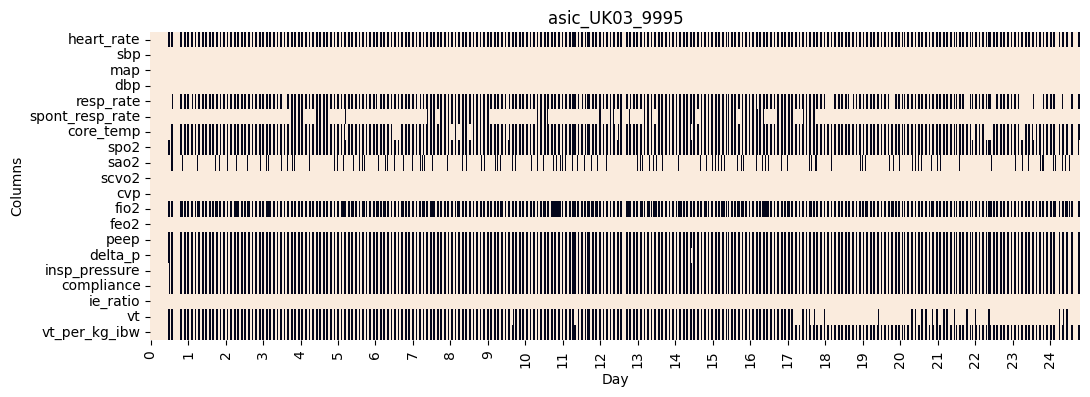

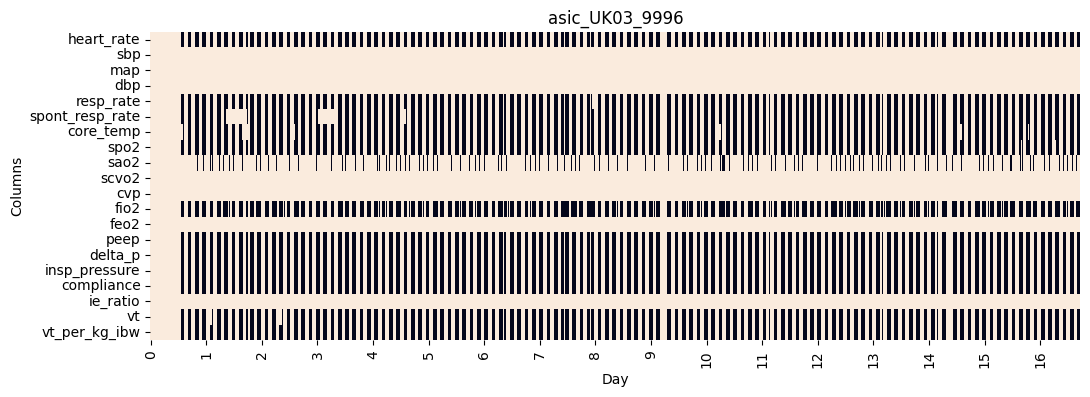

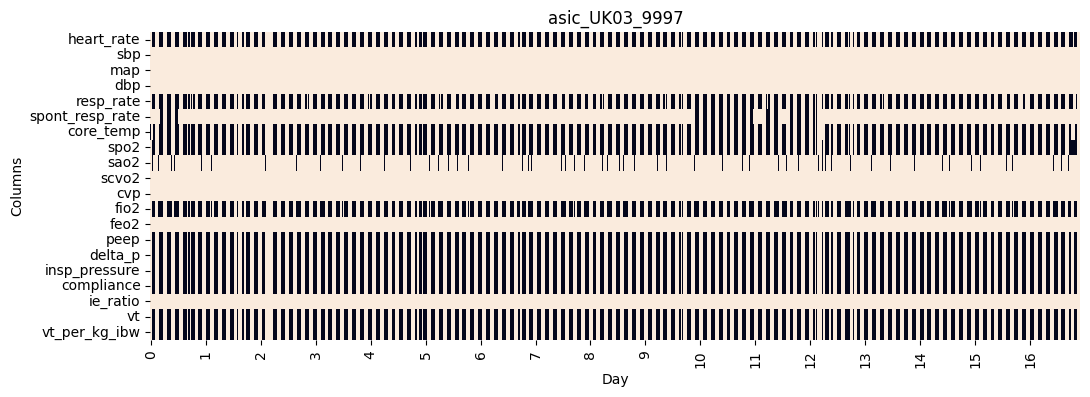

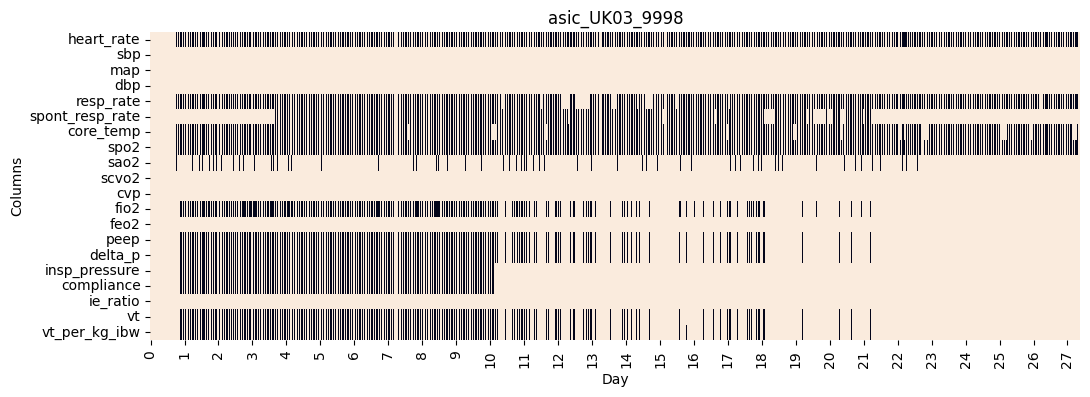

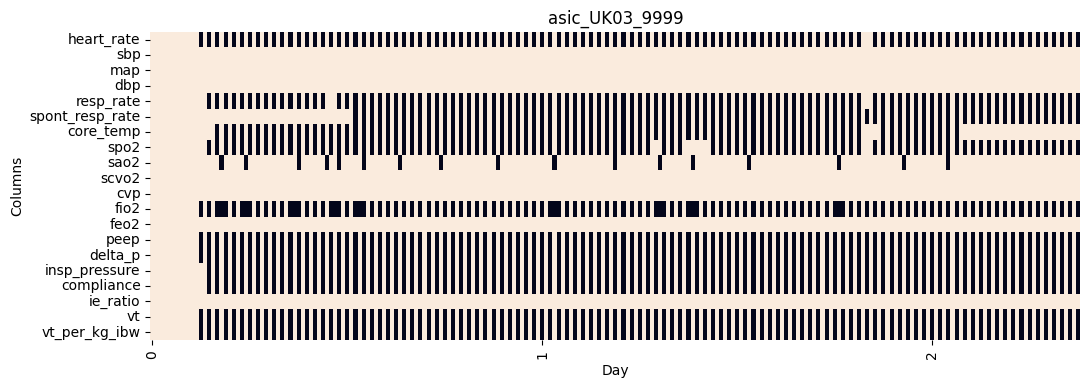

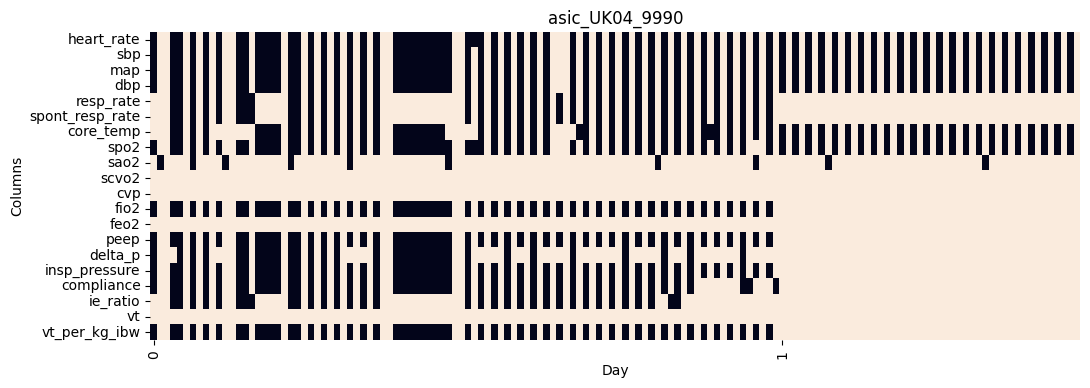

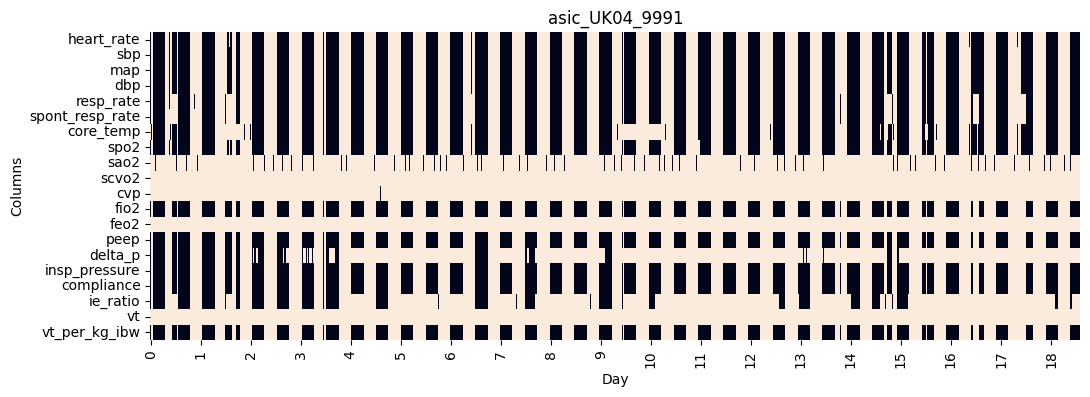

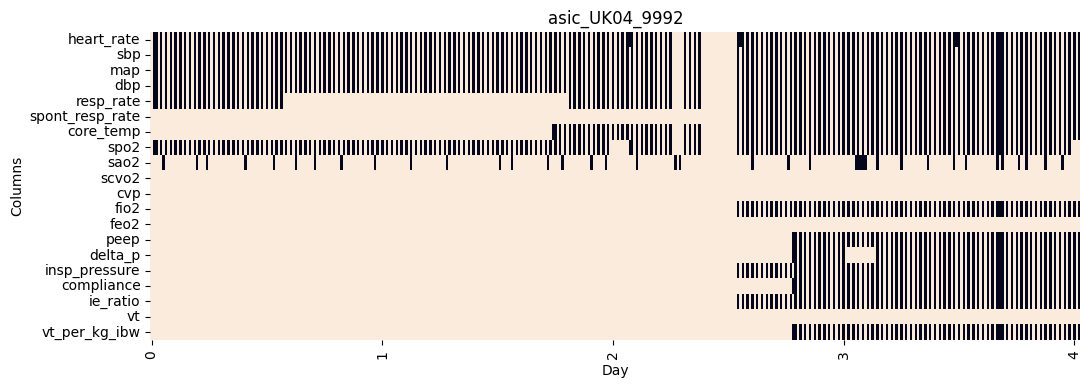

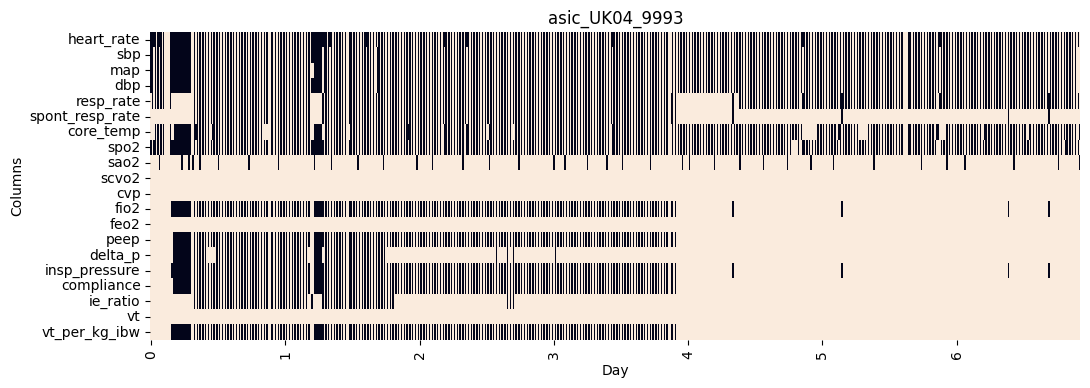

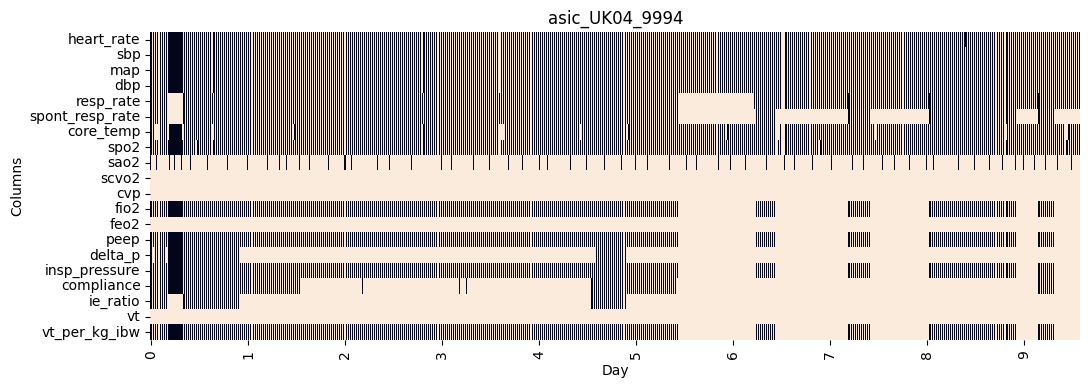

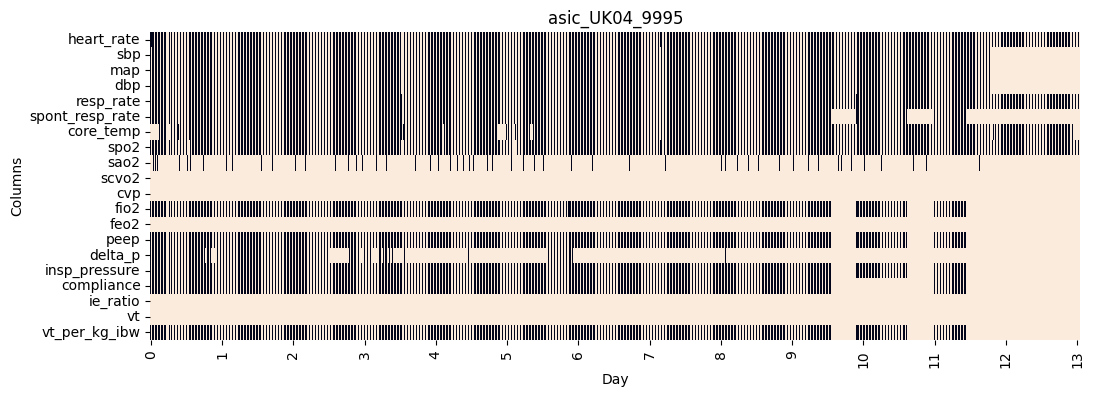

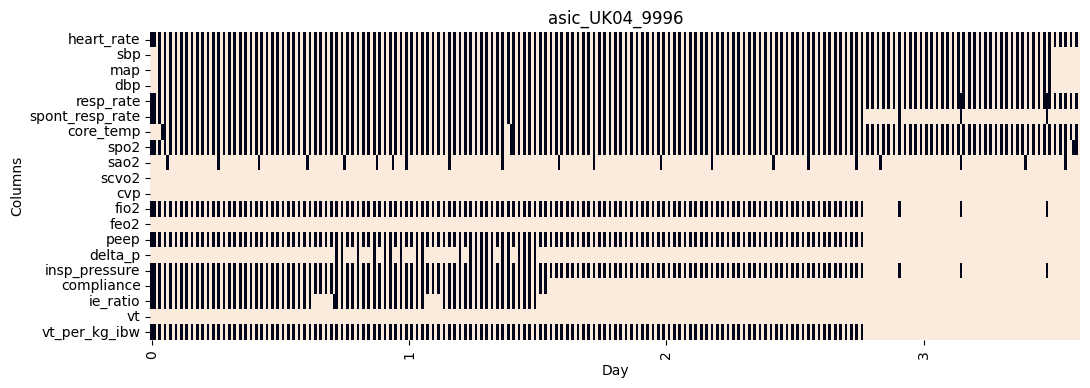

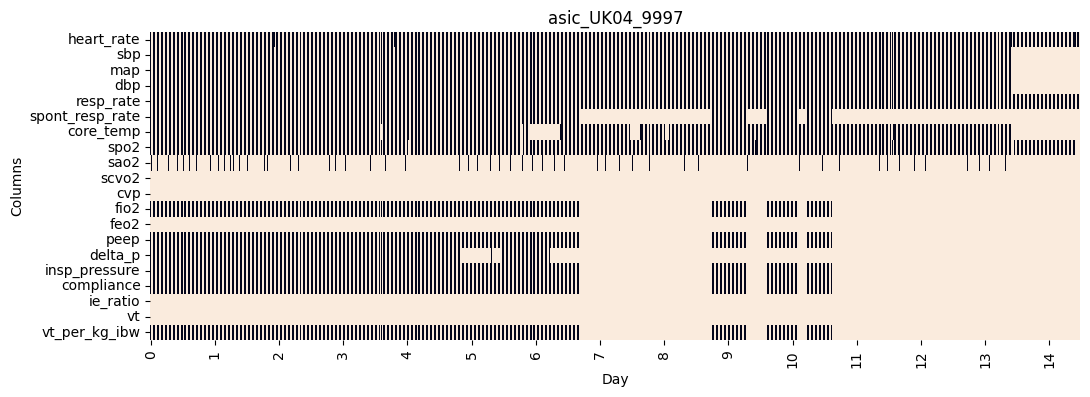

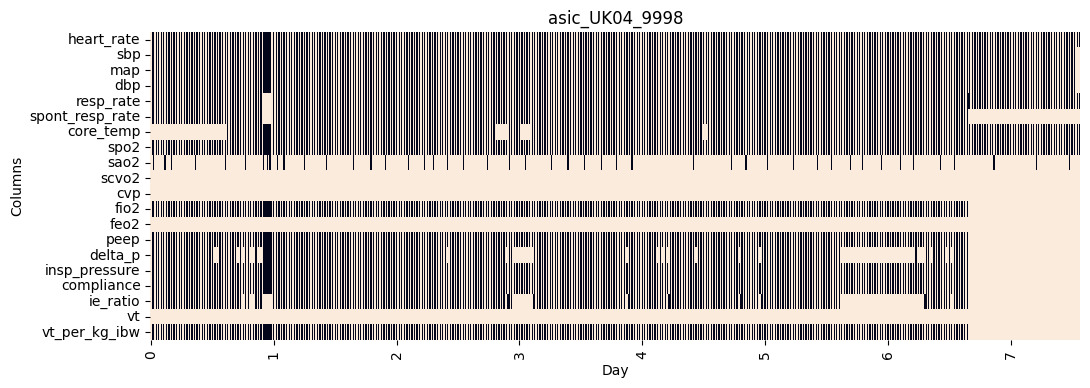

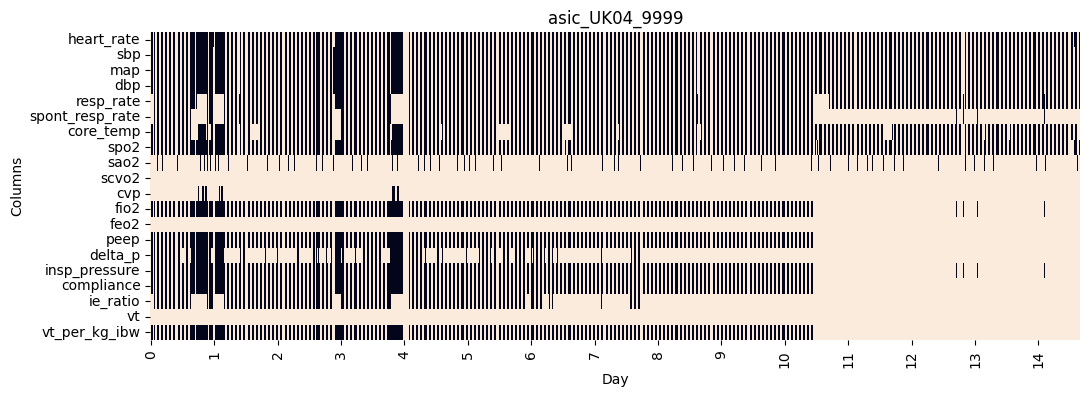

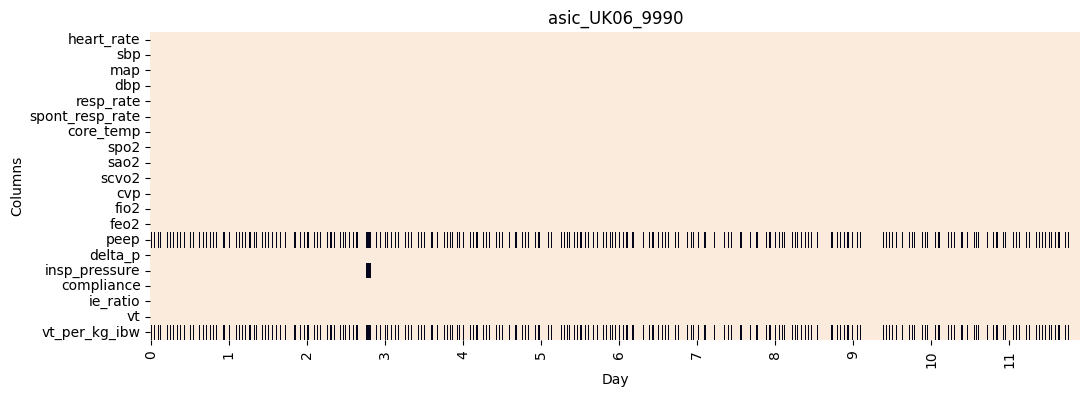

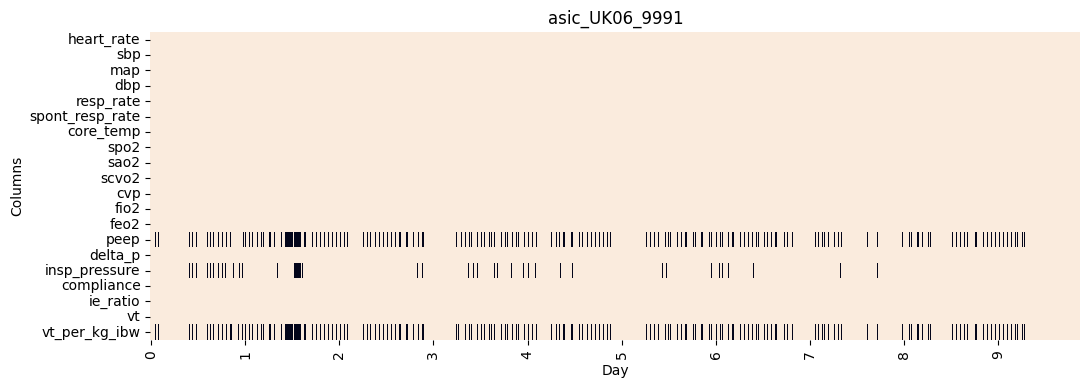

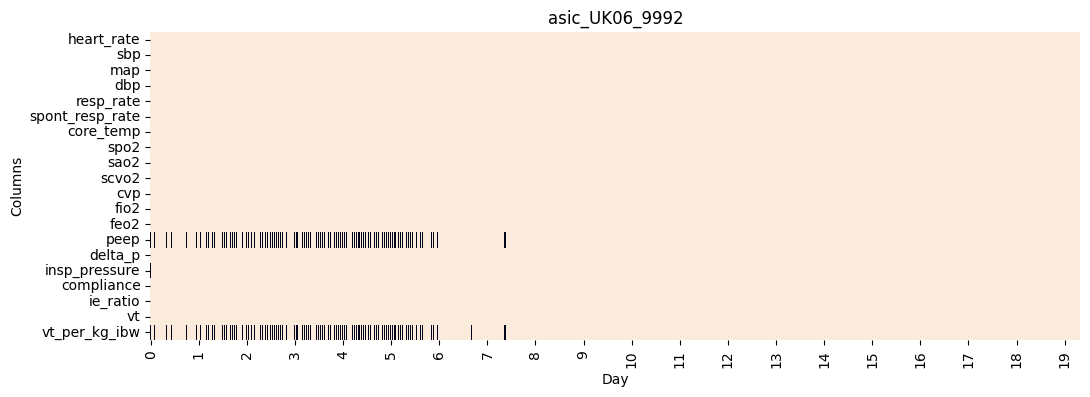

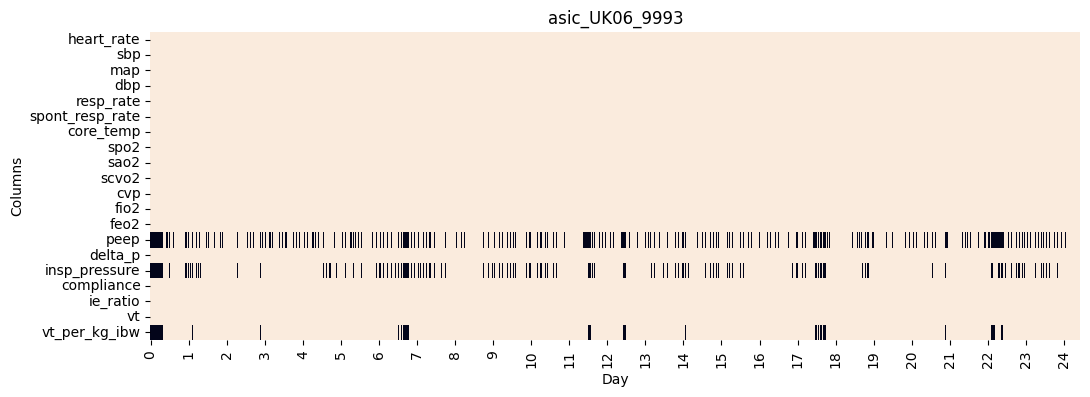

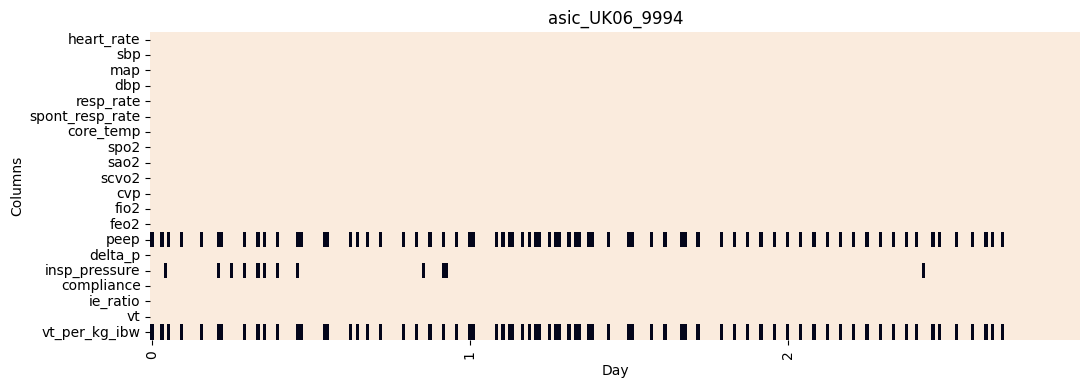

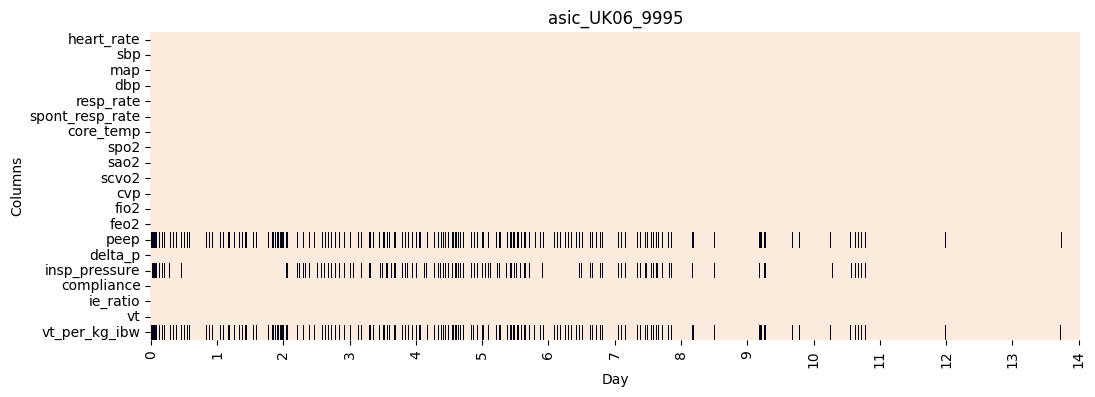

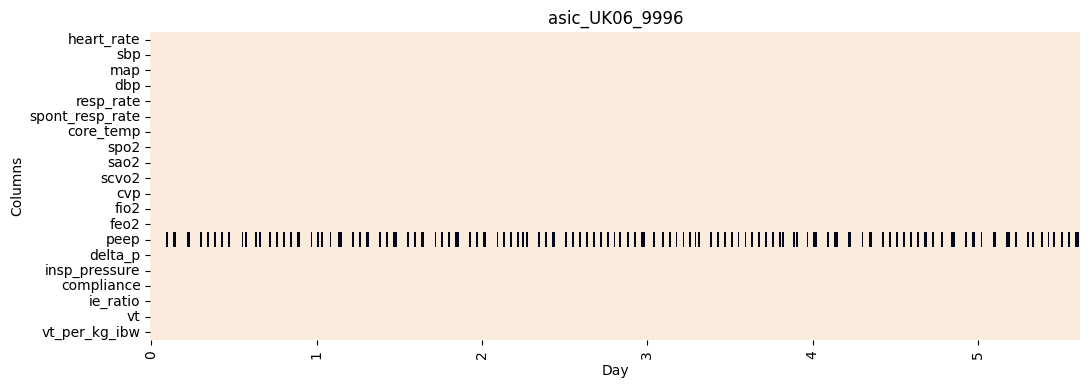

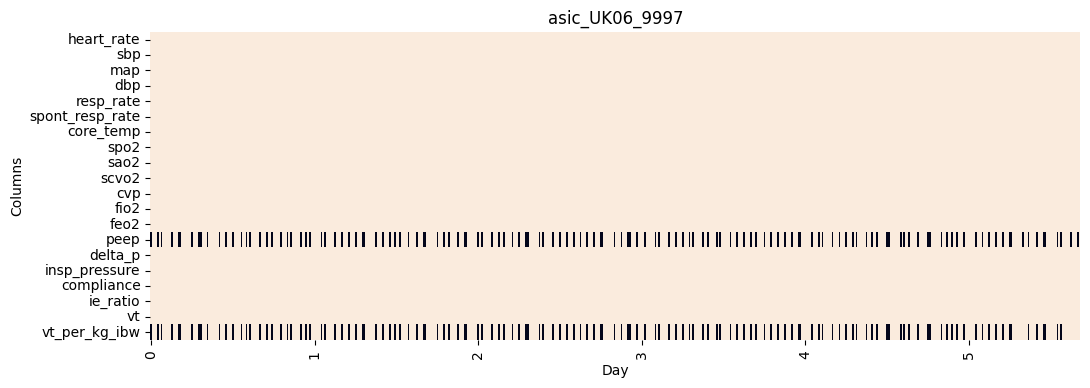

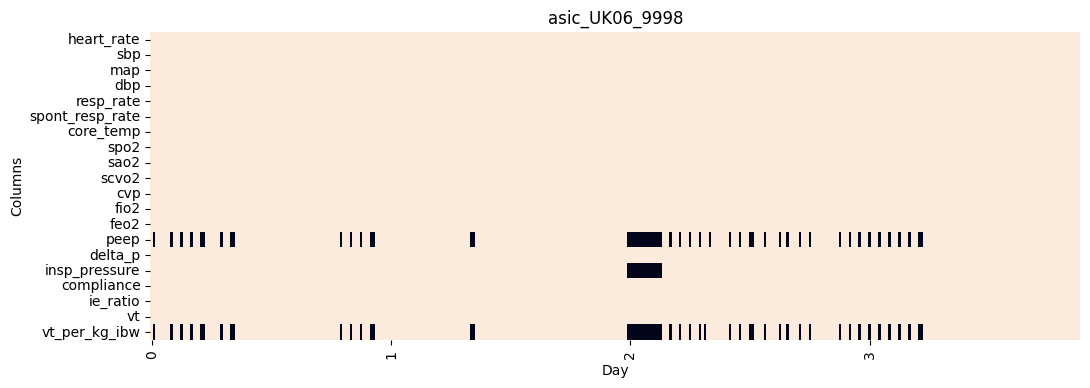

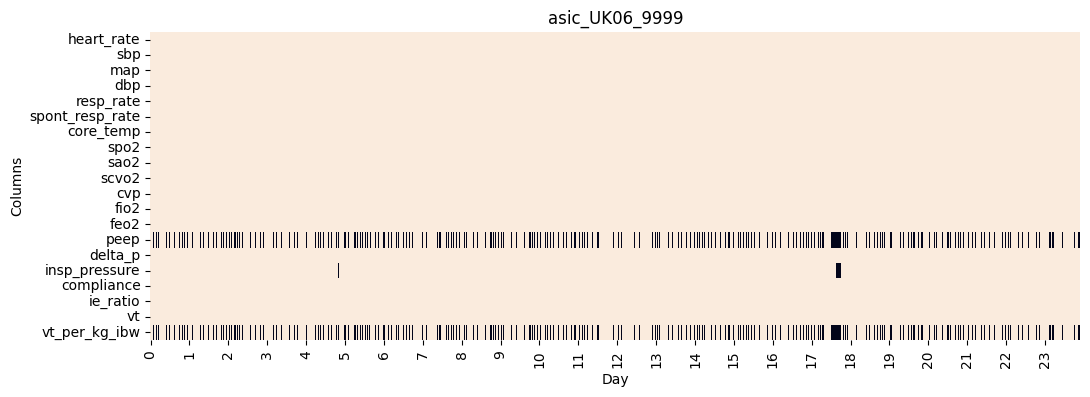

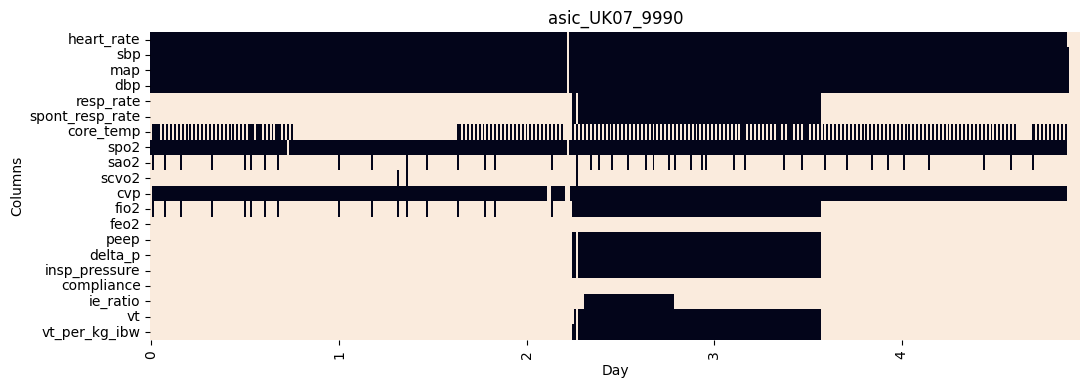

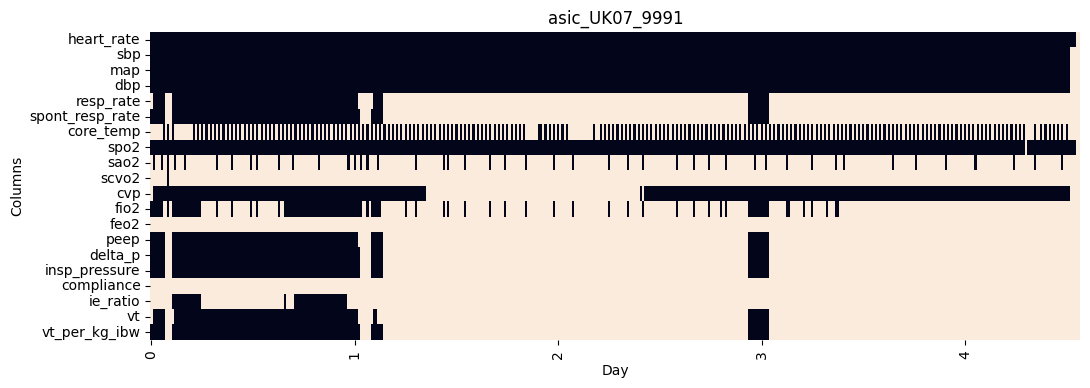

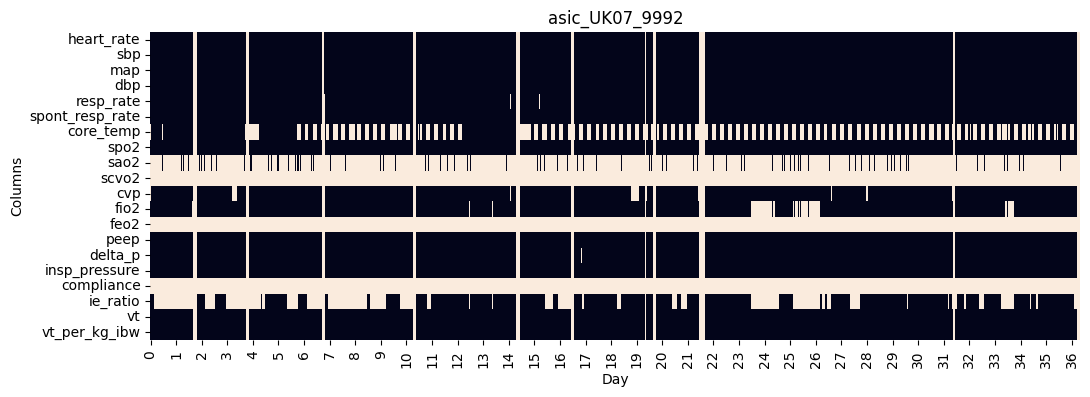

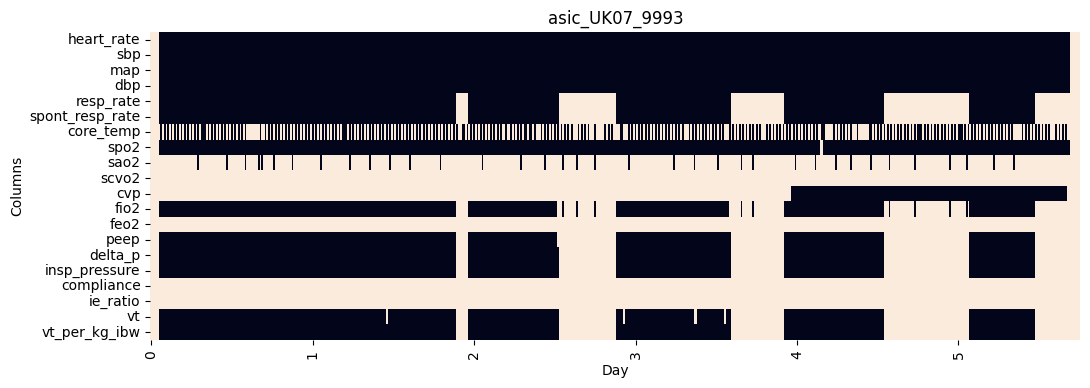

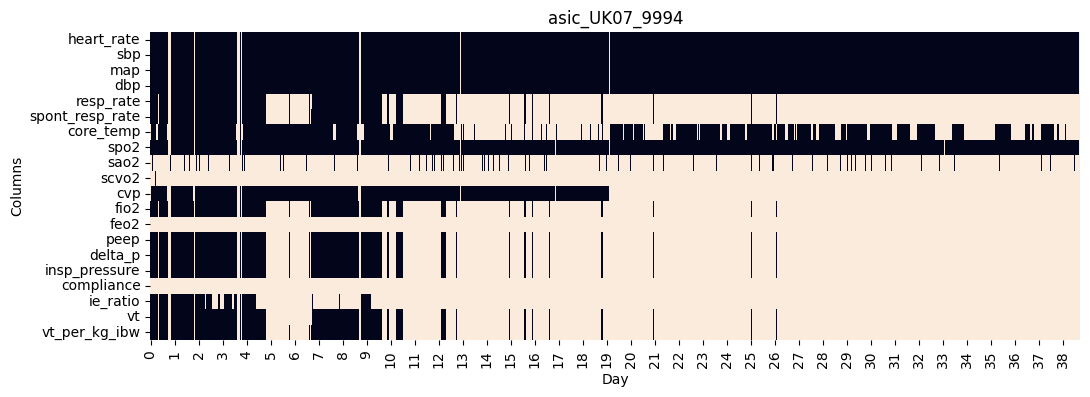

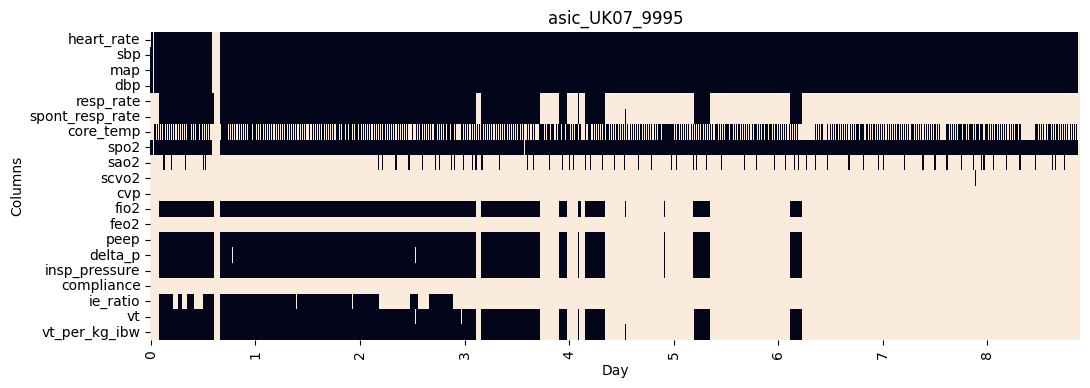

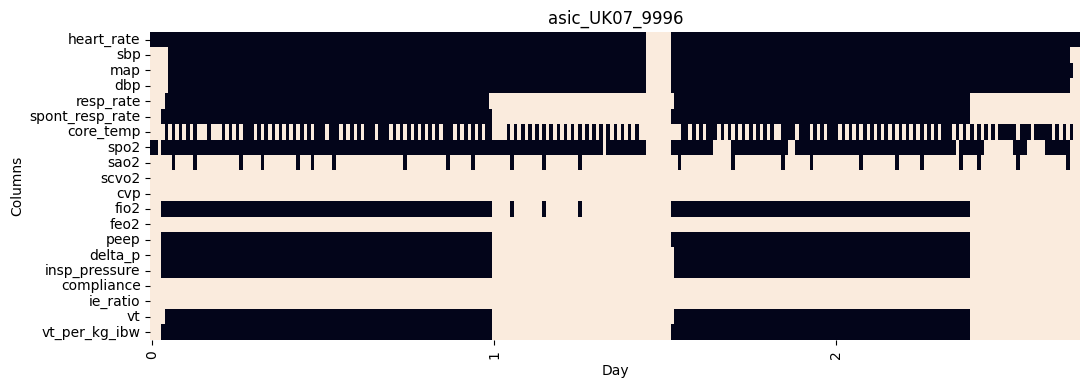

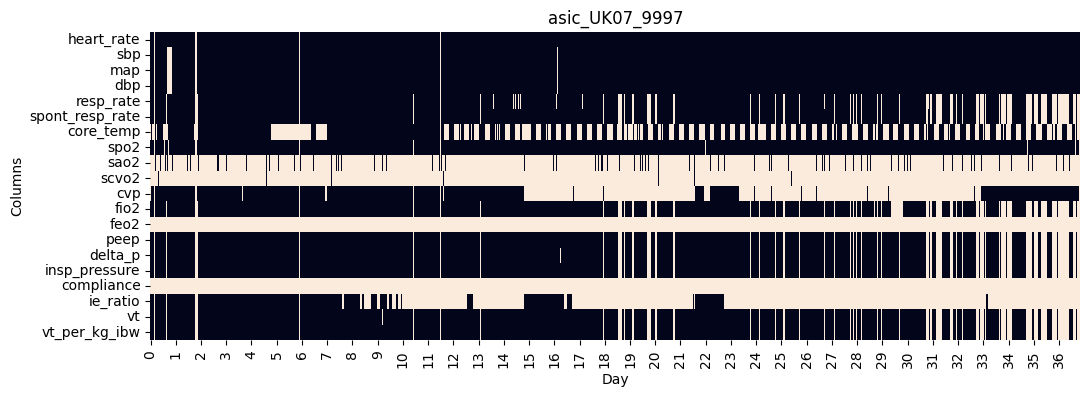

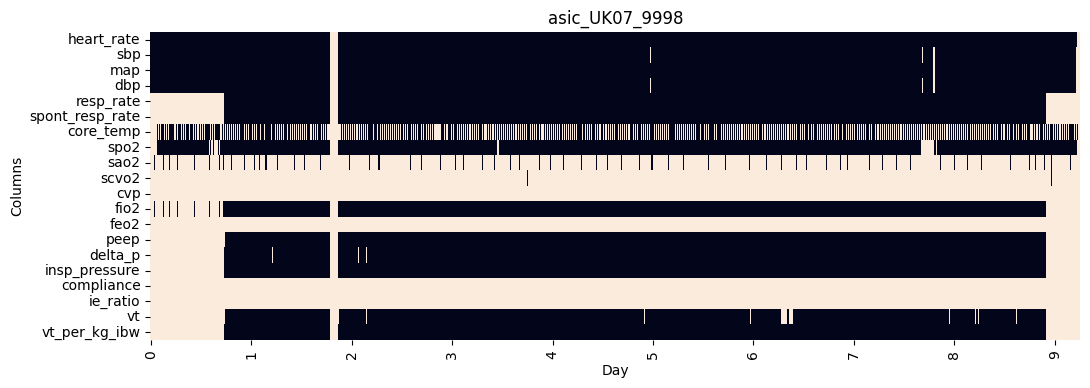

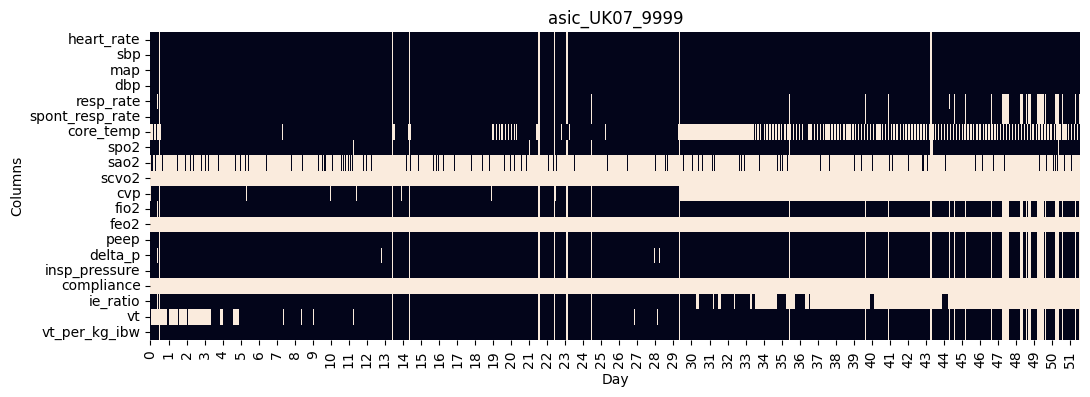

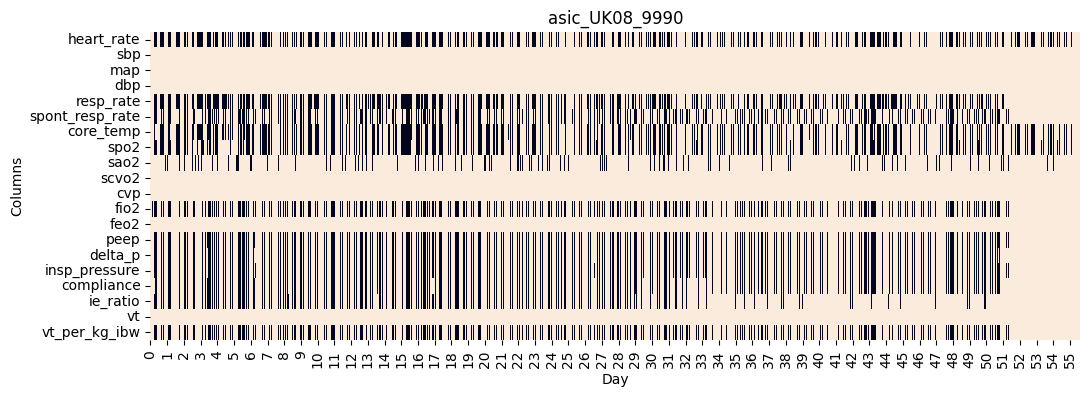

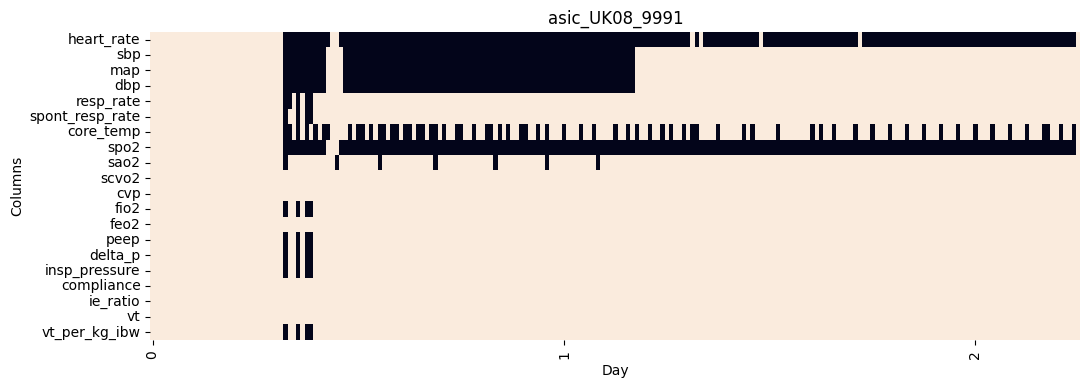

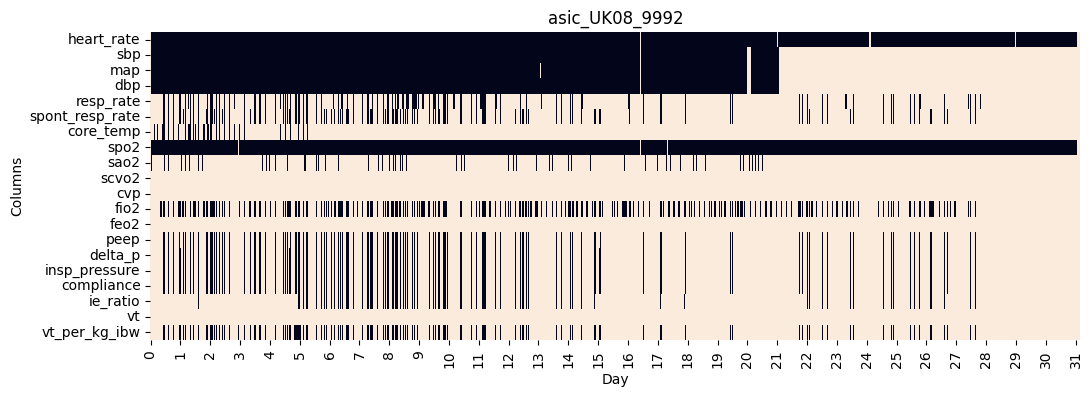

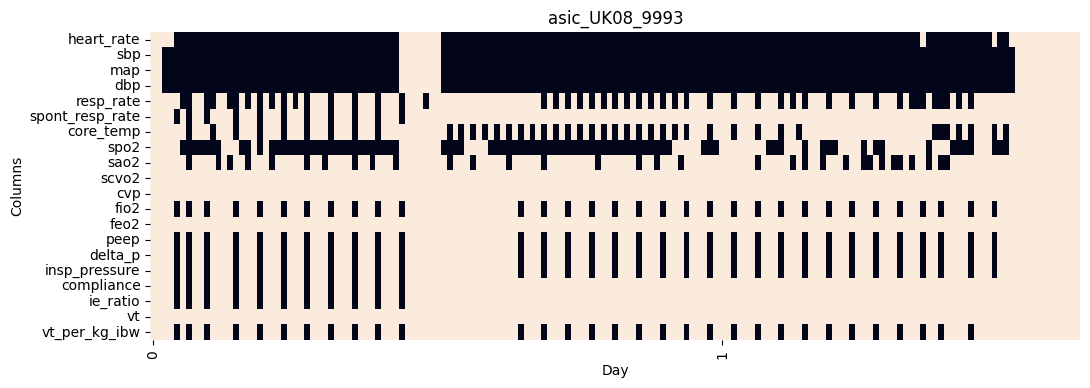

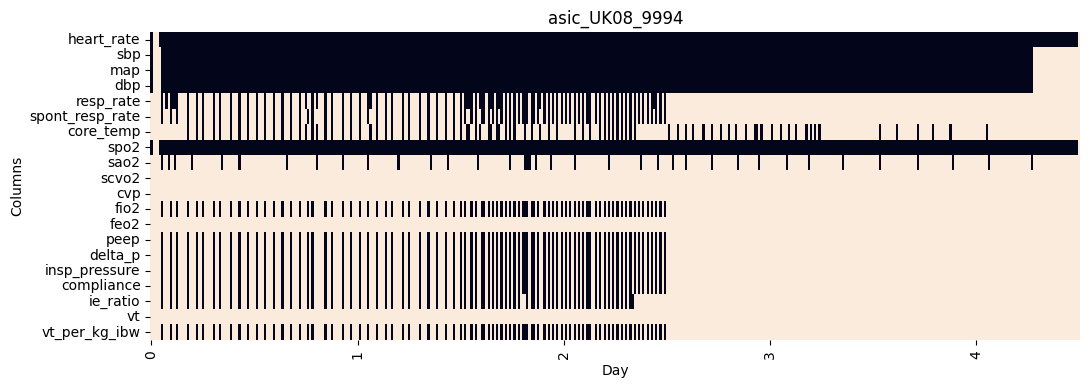

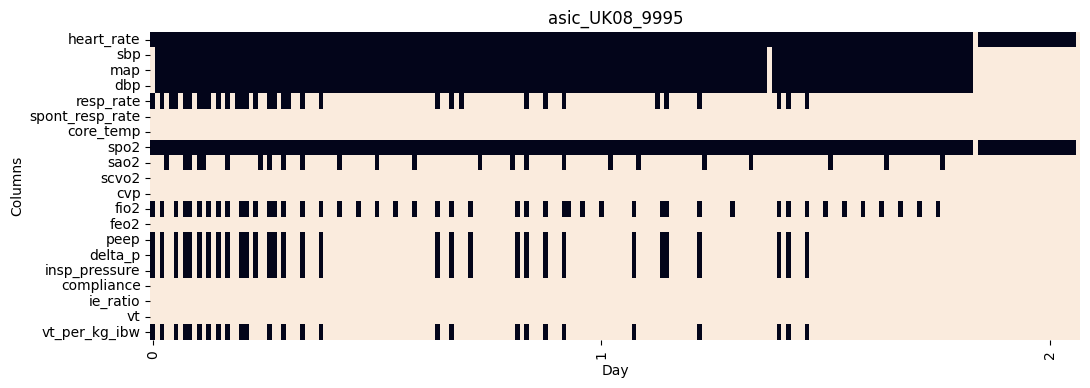

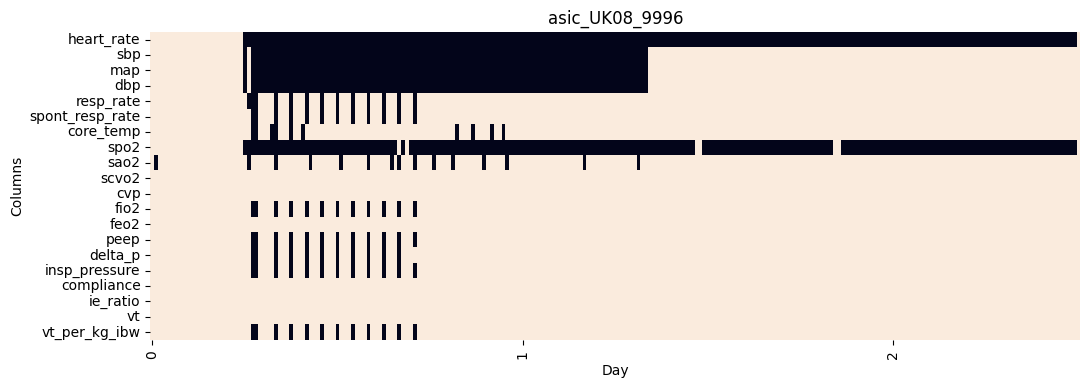

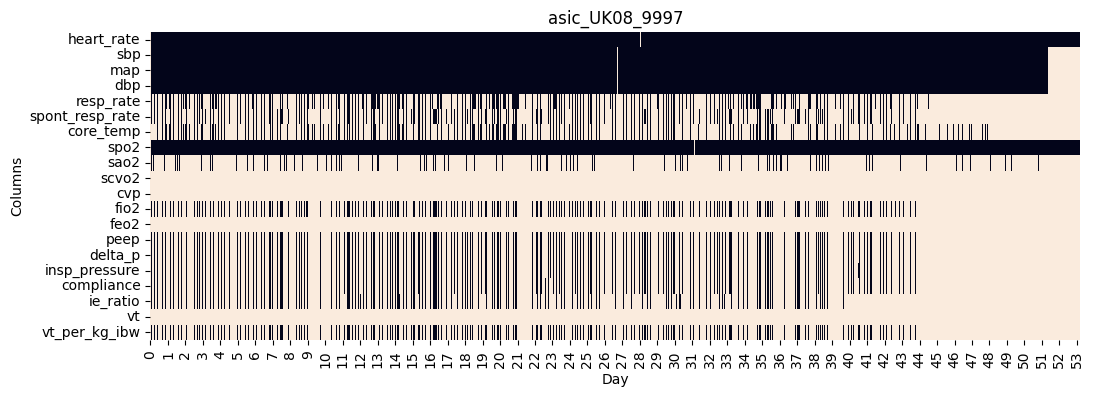

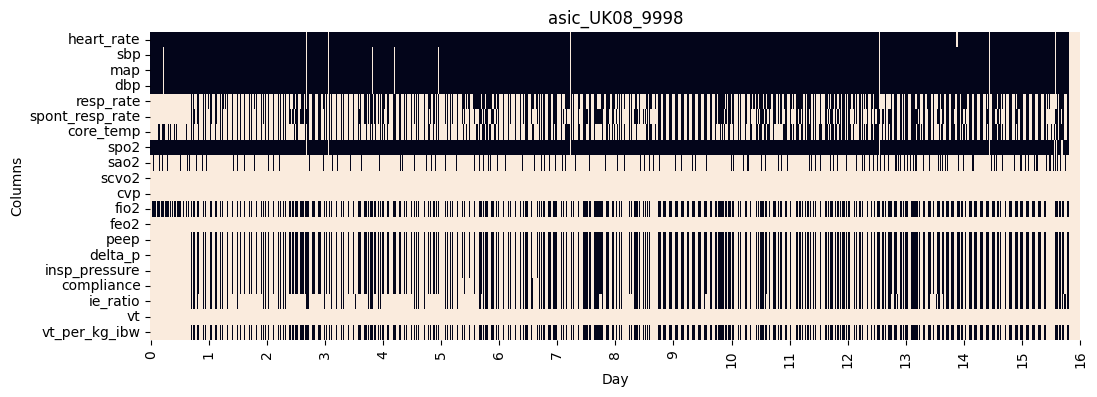

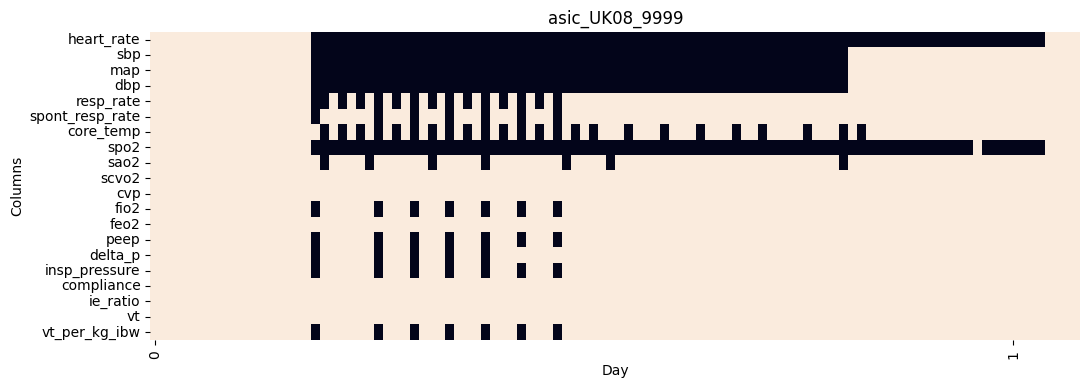

In [7]:
for stay_id_global, group in final_dynamic.groupby("stay_id_global"):
    
# stay_id_global = 'asic_UK00_9990'
# subset = final_dynamic[final_dynamic['stay_id_global'] == stay_id_global]
    columns_to_plot = final_dynamic.columns[5:25]

    plt.figure(figsize=(12, 4))
    ax = sns.heatmap(group[columns_to_plot].isnull().T, cbar=False)

    # 24 hours / 15 minutes = 96 rows per day
    day_step = 96
    n_rows = len(group)

    # Heatmap cell centers are at 0.5, 1.5, 2.5, ...
    day_positions = np.arange(0, n_rows, day_step) + 0.5
    day_labels = np.arange(len(day_positions))  # 0, 1, 2, ...

    ax.set_xticks(day_positions)
    ax.set_xticklabels(day_labels)

    plt.title(f'{stay_id_global}')
    plt.ylabel('Columns')
    plt.xlabel('Day')
    plt.show()

### Variable Missingness Pattern

hospital_id,asic_UK00,asic_UK01,asic_UK02,asic_UK03,asic_UK04,asic_UK06,asic_UK07,asic_UK08
heart_rate,False,True,False,False,False,True,False,False
sbp,False,True,False,True,False,True,False,False
map,False,True,False,True,False,True,False,False
dbp,False,True,False,True,False,True,False,False
resp_rate,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...
hydrocortisone_iv_bolus,True,True,True,False,True,True,False,False
prednisolone_iv_bolus,True,True,True,True,True,True,False,True
dexamethasone_iv_bolus,True,True,True,False,True,True,False,False
fludrocortisone_po_bolus,True,True,True,True,True,True,True,True


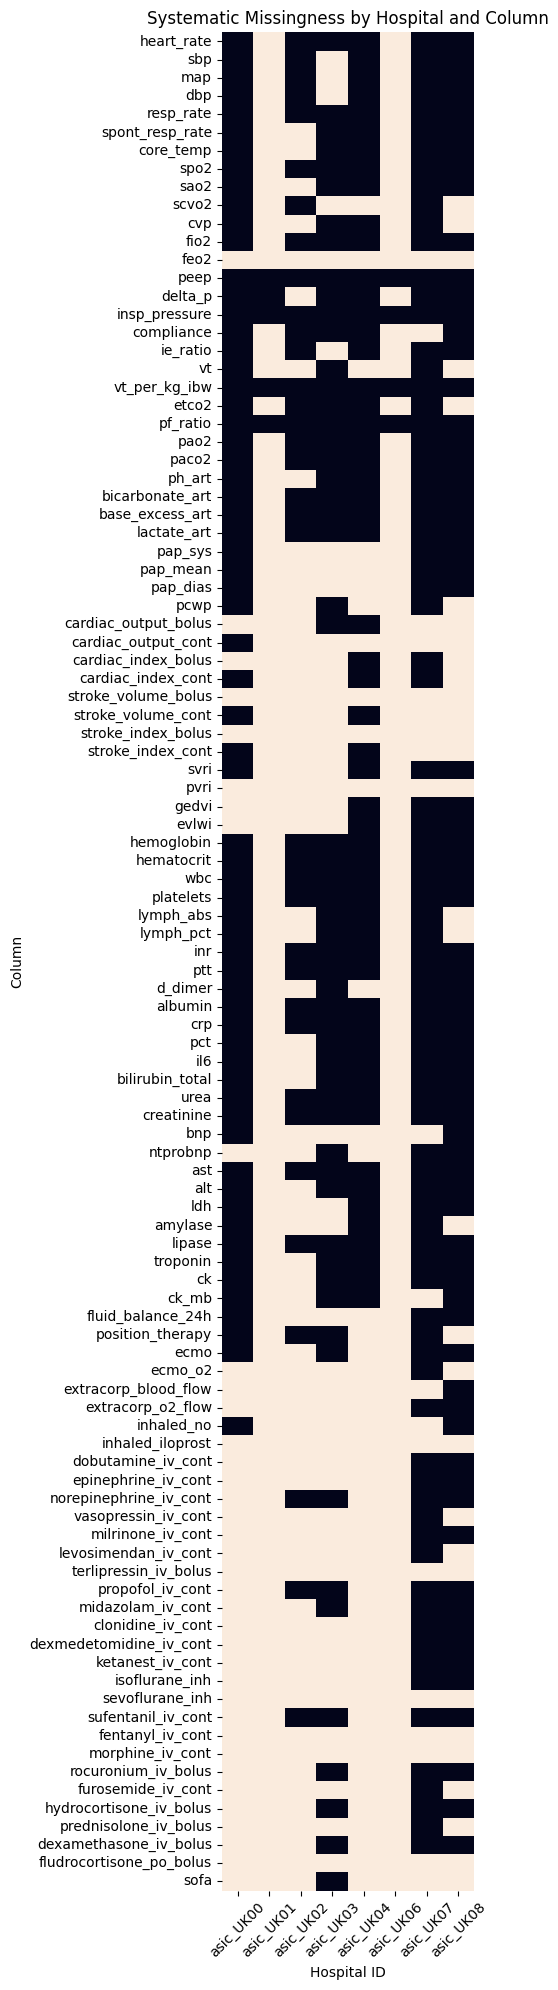

In [8]:
exclude_cols = ['hospital_id', 'stay_id_global', 'stay_id_local', 'time', 'minutes_since_admit']
cols_to_check = [c for c in final_dynamic.columns if c not in exclude_cols]

systematic_missing_matrix = (
    final_dynamic
    .groupby('hospital_id')[cols_to_check]
    .apply(lambda df: df.isna().all(axis=0))
    .T
)

display(systematic_missing_matrix)

# Plot missingness heatmap
plt.figure(figsize=(5, 20))
sns.heatmap(systematic_missing_matrix, cbar=False)
plt.title('Systematic Missingness by Hospital and Column')
plt.xlabel('Hospital ID')
plt.ylabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

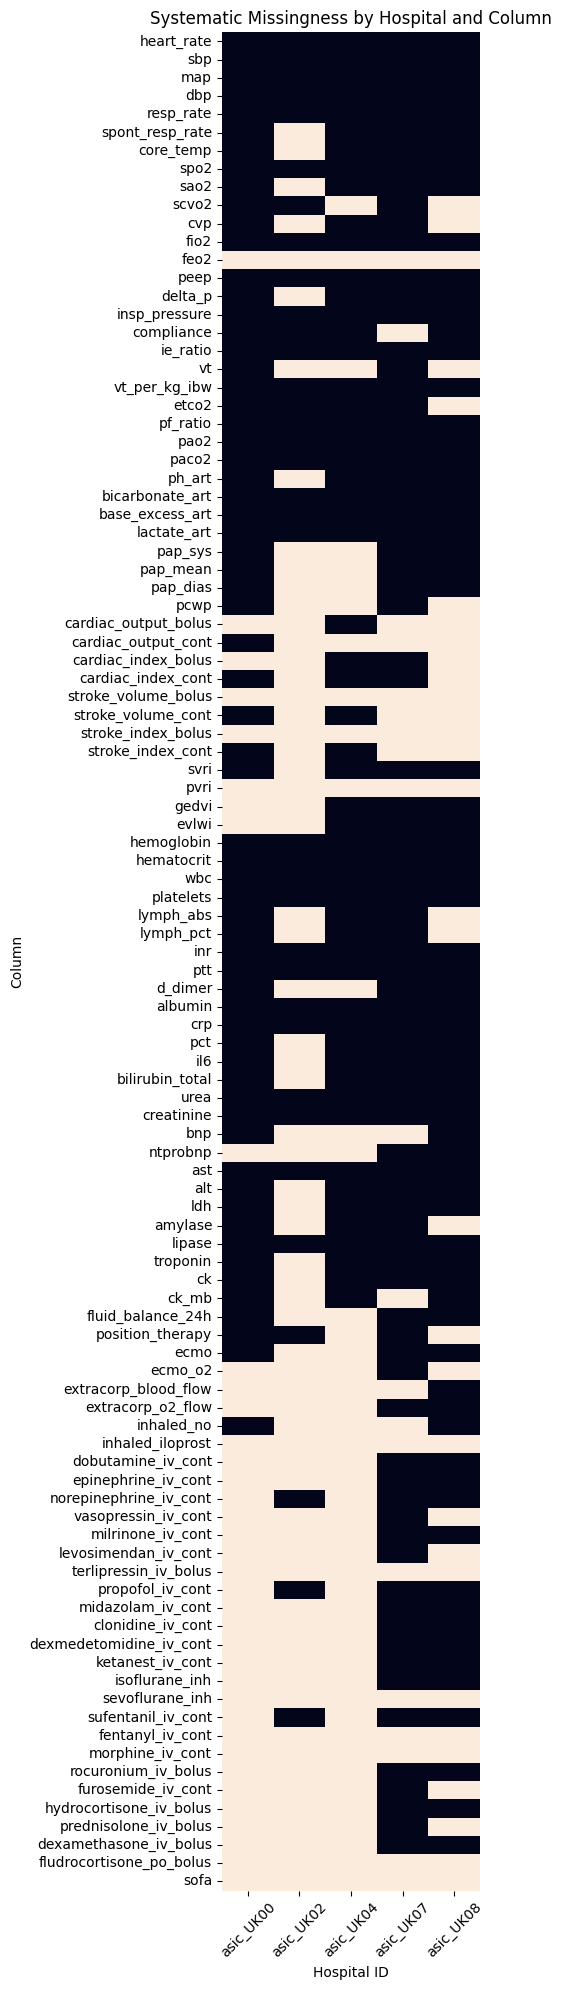

In [11]:
# Plot missingness heatmap
plt.figure(figsize=(5, 20))
sns.heatmap(systematic_missing_matrix.drop(columns=['asic_UK01', 'asic_UK03', 'asic_UK06']), cbar=False)
plt.title('Systematic Missingness by Hospital and Column')
plt.xlabel('Hospital ID')
plt.ylabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Semantic Harmonization
Making variables mean the same thing across hopsitals includes:
- unit correction
- invalid-value detection
- site-specifc variable exclusion when values are not trustworthy

In [16]:
check_cols = ['norepinephrine_iv_cont', 'clonidine_iv_cont', 'vt_per_kg_ibw', 'etco2', 'ie_ratio', 'lipase', 'pct']

# Provide value summaries for these columns grouped by hospitals
for col in check_cols:
    print(f"Column: {col}")
    display(final_dynamic.groupby('hospital_id')[col].describe())

Column: norepinephrine_iv_cont


,count,mean,std,min,25%,50%,75%,max
hospital_id,,,,,,,,
asic_UK00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK01,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK02,7601.0,0.137717,0.198329,0.010,0.040,0.07,0.160,2.000
asic_UK03,455.0,11.921273,5.579220,2.857,7.143,11.40,12.829,37.057
asic_UK04,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK06,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK07,11812.0,0.080178,0.121140,0.000,0.000,0.04,0.110,0.890
asic_UK08,11081.0,0.167920,0.602042,0.000,0.010,0.04,0.120,13.900


Column: clonidine_iv_cont


,count,mean,std,min,25%,50%,75%,max
hospital_id,,,,,,,,
asic_UK00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK01,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK02,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK03,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK04,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK06,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK07,8299.0,0.070480,0.037360,0.0,0.06,0.06,0.09,0.18
asic_UK08,1607.0,1.074723,0.708402,0.0,1.00,1.00,1.50,3.00


Column: vt_per_kg_ibw


...

,count,mean,std,min,25%,50%,75%,max
hospital_id,,,,,,,,
asic_UK00,1954.0,1.471237,0.422045,0.530000,1.200,1.500000,1.700000,5.9
asic_UK01,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK02,1194.0,0.818879,0.555185,0.185185,0.625,0.714286,0.909091,4.0
asic_UK03,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK04,1217.0,0.892269,0.242969,0.455000,0.769,1.000000,1.000000,1.7
asic_UK06,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK07,7288.0,1.250700,0.647655,0.530000,0.910,1.000000,1.400000,2.7
asic_UK08,2788.0,0.640577,0.227852,0.310000,0.530,0.590000,0.710000,2.0


Column: lipase


,count,mean,std,min,25%,50%,75%,max
hospital_id,,,,,,,,
asic_UK00,50.0,84.880000,92.931539,6.000,10.25000,34.0000,143.750,350.000
asic_UK01,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK02,134.0,106.352239,126.058068,0.000,25.80000,57.6000,123.300,521.400
asic_UK03,100.0,78.826880,89.338569,4.799,15.89725,39.8935,125.979,402.533
asic_UK04,3.0,12.000000,6.928203,4.000,10.00000,16.0000,16.000,16.000
asic_UK06,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK07,23.0,41.652174,25.302908,9.000,14.00000,50.0000,63.000,76.000
asic_UK08,11.0,63.636364,50.012544,17.000,26.50000,30.0000,107.000,142.000


Column: pct


,count,mean,std,min,25%,50%,75%,max
hospital_id,,,,,,,,
asic_UK00,114.0,6.168158,17.195651,0.03,0.080,0.220,0.90,98.82
asic_UK01,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK02,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK03,225.0,3.328489,6.917936,0.02,0.310,0.680,2.59,48.20
asic_UK04,30.0,1.991667,3.372052,0.08,0.135,0.420,2.12,10.80
asic_UK06,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
asic_UK07,200.0,2.412850,3.437953,0.02,0.410,1.215,2.61,30.20
asic_UK08,164.0,1.664634,4.597832,0.04,0.170,0.375,0.87,34.17
